# Setup Steps

## Imports

In [ ]:
import cv2
import numpy as np
import psycopg2
import json
import os
import urllib.request
from datetime import datetime
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import Button
from IPython.display import display, clear_output
from deepface import DeepFace
import torch
import torchreid

## Creating the database 

Define database credentials

In [2]:

DB_HOST = "localhost"
DB_PORT = 5432
DB_NAME = "retail_cv_deep_dive"
DB_USER = "postgres"
DB_PASSWORD = "abc123"

In [3]:
conn = psycopg2.connect(
    host=DB_HOST,
    port=DB_PORT,
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD
)
cursor = conn.cursor()
print("Database connection successful.")

Database connection successful.


Create the database connection and define the table structure.

In [ ]:

# create zones table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS zones (
        zone_id               SERIAL PRIMARY KEY,
        zone_name             VARCHAR(100),
        camera_id             VARCHAR(50),
        polygon_coordinates   JSONB,
        floor                 VARCHAR(20),
        zone_type             VARCHAR(50),
        reid_enabled          BOOLEAN DEFAULT FALSE,
        UNIQUE (zone_name, camera_id)       
    )
""")
print("Zones table created.")

#create rules table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS rules (
        rule_id               SERIAL PRIMARY KEY,
        rule_name             VARCHAR(100),
        zone_id               INT REFERENCES zones(zone_id),
        trigger_condition     VARCHAR(255),
        threshold_min         FLOAT,
        threshold_max         FLOAT,
        severity              VARCHAR(20),
        rule_type             VARCHAR(50),
        active                BOOLEAN DEFAULT TRUE
    )
""")
print("Rules table created.")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS detection_events (
        unique_detection_id   SERIAL PRIMARY KEY,
        timestamp             TIMESTAMP,
        frame_number          INT,
        camera_id             VARCHAR(50),
        zone_id               INT REFERENCES zones(zone_id),
        polygon_zone_id       INT REFERENCES zones(zone_id),
        model_name            VARCHAR(100),
        object_class          VARCHAR(50),
        confidence            FLOAT,
        bbox                  JSONB,
        track_id              VARCHAR(50),
        reid_type             VARCHAR(20),
        reid_id               VARCHAR(50),
        previous_zone_id      INT REFERENCES zones(zone_id),
        movement_type         VARCHAR(20),
        direction             VARCHAR(20),
        movement_direction    VARCHAR(20),
        dwell_time            FLOAT,
        object_count_in_zone  INT,
        processing_latency    FLOAT,
        image_path            VARCHAR(255)
    )
""")
print("Detection events table created.")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS emotion_events (
        unique_detection_id   INT REFERENCES detection_events(unique_detection_id),
        emotion               VARCHAR(50),
        confidence            FLOAT,
        bbox                  JSONB
    )
""")
print("Emotion events table created.")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS notifications (
        notification_id       SERIAL PRIMARY KEY,
        timestamp             TIMESTAMP,
        rule_id               INT REFERENCES rules(rule_id),
        unique_detection_id   INT REFERENCES detection_events(unique_detection_id),
        zone_id               INT REFERENCES zones(zone_id),
        camera_id             VARCHAR(50),
        trigger_value         JSONB,
        message               VARCHAR(255),
        image_path            VARCHAR(255)
    )
""")
print("Notifications table created.")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS reid_features (
        reid_id        VARCHAR(50) PRIMARY KEY,
        feature_vector JSONB,
        last_seen      TIMESTAMP,
        last_zone_id   INT REFERENCES zones(zone_id),
        last_camera_id VARCHAR(50),
        status         VARCHAR(20) DEFAULT 'active'
    )
""")
print("ReID features table created.")

conn.commit()
print("All 6 tables ready.")

## Helper Functions

In [4]:
#Toggle
SAVE_OUTPUT_VIDEO = True
DB_WRITE_ENABLED  = True

# ── DATABASE ───────────────────────────────────────────────────────────────
cursor = conn.cursor()

def write_detection_event(
    frame_number, camera_id, zone_id, polygon_zone_id,
    model_name, object_class, confidence, bbox,
    track_id=None, reid_type=None, reid_id=None,
    previous_zone_id=None, movement_type=None,
    direction=None, movement_direction=None,
    dwell_time=None, object_count_in_zone=None,
    processing_latency=None,
    timestamp=None,          
    image_path=None         
):
    """Insert a detection event and return its unique_detection_id."""
    if not DB_WRITE_ENABLED:
        return None

    event_timestamp = timestamp if timestamp is not None else datetime.now()

    cursor.execute("""
        INSERT INTO detection_events (
            timestamp, frame_number, camera_id, zone_id, polygon_zone_id,
            model_name, object_class, confidence, bbox, track_id,
            reid_type, reid_id, previous_zone_id, movement_type,
            direction, movement_direction, dwell_time,
            object_count_in_zone, processing_latency, image_path
        ) VALUES (
            %s, %s, %s, %s, %s,
            %s, %s, %s, %s, %s,
            %s, %s, %s, %s,
            %s, %s, %s,
            %s, %s, %s
        ) RETURNING unique_detection_id
    """, (
        event_timestamp, frame_number, camera_id, zone_id, polygon_zone_id,
        model_name, object_class, float(confidence), json.dumps(bbox), track_id,
        reid_type, reid_id, previous_zone_id, movement_type,
        direction, movement_direction, dwell_time,
        object_count_in_zone, float(processing_latency) if processing_latency else None,
        image_path
    ))
    conn.commit()
    return cursor.fetchone()[0]

def compute_movement_direction(prev_point, curr_point):
    """
    Compute frame-to-frame movement direction inside a zone.
    prev_point and curr_point are pixel coordinates (x, y).
    Returns 'left', 'right', 'up', 'down', or None if no previous point.
    """
    if prev_point is None:
        return None

    dx = curr_point[0] - prev_point[0]
    dy = curr_point[1] - prev_point[1]

    # Ignore micro-movements (noise threshold)
    if abs(dx) < 3 and abs(dy) < 3:
        return None

    if abs(dx) > abs(dy):
        return "right" if dx > 0 else "left"
    else:
        return "down" if dy > 0 else "up"

def write_emotion_event(unique_detection_id, emotion, confidence, bbox):
    """Insert an emotion event linked to a detection event."""
    if not DB_WRITE_ENABLED:
        return
    cursor.execute("""
        INSERT INTO emotion_events (unique_detection_id, emotion, confidence, bbox)
        VALUES (%s, %s, %s, %s)
    """, (
        unique_detection_id,
        emotion,
        float(confidence),        # convert numpy.float32 to Python float
        json.dumps(bbox)
    ))
    conn.commit()


def write_notification(rule_id, unique_detection_id, zone_id, camera_id, trigger_value, message):
    """Insert a notification event."""
    if not DB_WRITE_ENABLED:
        return
    cursor.execute("""
        INSERT INTO notifications 
        (timestamp, rule_id, unique_detection_id, zone_id, camera_id, trigger_value, message)
        VALUES (%s, %s, %s, %s, %s, %s, %s)
    """, (
        datetime.now(),
        rule_id,
        unique_detection_id,
        zone_id,
        camera_id,
        json.dumps(trigger_value),
        message
    ))
    conn.commit()


# ── GEOMETRY ───────────────────────────────────────────────────────────────

def point_in_polygon(point, polygon):
    """Check if a point (x, y) is inside a polygon using ray casting."""
    x, y = point
    n = len(polygon)
    inside = False
    px, py = polygon[0]
    for i in range(1, n + 1):
        cx, cy = polygon[i % n]
        if ((py > y) != (cy > y)) and (x < (cx - px) * (y - py) / (cy - py) + px):
            inside = not inside
        px, py = cx, cy
    return inside


def get_bbox_center_normalized(bbox, frame_width, frame_height):
    """Return the normalized center point of a bounding box."""
    cx = ((bbox["x1"] + bbox["x2"]) / 2) / frame_width
    cy = ((bbox["y1"] + bbox["y2"]) / 2) / frame_height
    return (cx, cy)


def get_direction(prev_center, curr_center):
    """Return movement direction based on two center points."""
    dx = curr_center[0] - prev_center[0]
    dy = curr_center[1] - prev_center[1]
    if abs(dx) > abs(dy):
        return "right" if dx > 0 else "left"
    else:
        return "down" if dy > 0 else "up"


# ── DRAWING ────────────────────────────────────────────────────────────────

def draw_overlay(frame, bbox, label, color=(0, 255, 0)):
    """Draw bounding box and label on a frame."""
    x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]

    # Draw bounding box
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

    # Draw label background for readability
    label_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    cv2.rectangle(frame,
                  (x1, y1 - label_size[1] - 6),
                  (x1 + label_size[0], y1),
                  color, -1)

    # Draw label text in black on coloured background
    cv2.putText(frame, label, (x1, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    return frame


def draw_polygon_zones(frame, polygon_zones):
    """Draw all defined polygon zones on a frame."""
    for zone in polygon_zones:
        pts = np.array(zone["polygon_coordinates"]["points"], np.int32)
        pts = pts.reshape((-1, 1, 2))
        cv2.polylines(frame, [pts], isClosed=True, color=(255, 165, 0), thickness=2)
        cx = int(np.mean([p[0] for p in zone["polygon_coordinates"]["points"]]))
        cy = int(np.mean([p[1] for p in zone["polygon_coordinates"]["points"]]))
        cv2.putText(frame, zone["zone_name"], (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)
    return frame


# ── EMOTION ────────────────────────────────────────────────────────────────

def classify_emotion(face_crop):
    """
    Run DeepFace emotion classification on a face crop.
    Returns dominant_emotion and its normalised confidence (0-1).
    DeepFace docs: https://pypi.org/project/deepface/
    """
    try:
        result = DeepFace.analyze(
            img_path         = face_crop,
            actions          = ["emotion"],
            enforce_detection = False,
            silent           = True
        )
        dominant_emotion = result[0]["dominant_emotion"]
        confidence       = result[0]["emotion"][dominant_emotion] / 100
        return dominant_emotion, confidence

    except Exception as e:
        return None, None


def crop_face(frame, bbox):
    """Crop a face region from a frame using bounding box coordinates."""
    x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]
    return frame[y1:y2, x1:x2]

# DetectNet_v2 grid settings matching PeopleNet input size 960x544
GRID_W      = 60
GRID_H      = 34
INPUT_W     = 960
INPUT_H     = 544
NUM_CLASSES = 3
class_map   = {0: "person", 1: "bag", 2: "face"}

def parse_peoplenet_detections(bbox_output, cov_output, confidence_threshold, orig_w, orig_h):
    """
    Parse PeopleNet DetectNet_v2 ONNX output.
    Source: https://github.com/NVIDIA-TAO/tao-deploy/blob/main/nvidia_tao_deploy/cv/detectnet_v2/postprocessor.py
    
    When train_img_size is not set, it defaults to bbox_norm = (35, 35).
    gc_centers are divided by bbox_norm, then bbox values subtract/add gc_centers,
    then multiply by train_img_size (35) to get pixel coordinates at model input scale,
    then scale to original frame size.
    """
    detections  = []
    stride      = 16
    bbox_norm   = 35.0
    bbox_offset = 0.5
    scale_x     = orig_w / INPUT_W
    scale_y     = orig_h / INPUT_H

    gc_centers_x = (np.arange(GRID_W) * stride + bbox_offset) / bbox_norm
    gc_centers_y = (np.arange(GRID_H) * stride + bbox_offset) / bbox_norm

    for cls_id in range(NUM_CLASSES):
        confidences = cov_output[0, cls_id]
        bbox_ch     = bbox_output[0, cls_id * 4: cls_id * 4 + 4]

        for row in range(GRID_H):
            for col in range(GRID_W):
                conf = float(confidences[row, col])
                if conf < confidence_threshold:
                    continue

                gcx = gc_centers_x[col]
                gcy = gc_centers_y[row]

                raw_x1 = float(bbox_ch[0, row, col])
                raw_y1 = float(bbox_ch[1, row, col])
                raw_x2 = float(bbox_ch[2, row, col])
                raw_y2 = float(bbox_ch[3, row, col])

                # Subtract gc_center then multiply by -bbox_norm for x1/y1
                # Add gc_center then multiply by bbox_norm for x2/y2
                # Then scale to original frame dimensions
                x1 = int((raw_x1 - gcx) * -bbox_norm * scale_x)
                y1 = int((raw_y1 - gcy) * -bbox_norm * scale_y)
                x2 = int((raw_x2 + gcx) *  bbox_norm * scale_x)
                y2 = int((raw_y2 + gcy) *  bbox_norm * scale_y)

                # Clamp to frame bounds
                x1 = max(0, min(x1, orig_w))
                y1 = max(0, min(y1, orig_h))
                x2 = max(0, min(x2, orig_w))
                y2 = max(0, min(y2, orig_h))

                if x2 <= x1 or y2 <= y1:
                    continue

                detections.append({
                    "object_class" : class_map[cls_id],
                    "confidence"   : conf,
                    "bbox"         : {"x1": x1, "y1": y1, "x2": x2, "y2": y2}
                })

    return detections

def apply_nms(detections, iou_threshold=0.3):
    """
    Apply Non-Maximum Suppression to remove overlapping detections.
    Groups by object_class and suppresses lower-confidence overlapping boxes.
    """
    if not detections:
        return []
    
    # Filter out zero-size boxes first
    detections = [
        d for d in detections
        if d["bbox"]["x2"] > d["bbox"]["x1"] and d["bbox"]["y2"] > d["bbox"]["y1"]
    ]
    
    # Group by class
    class_groups = {}
    for det in detections:
        cls = det["object_class"]
        if cls not in class_groups:
            class_groups[cls] = []
        class_groups[cls].append(det)

    results = []

    for cls, dets in class_groups.items():
        # Sort by confidence descending
        dets = sorted(dets, key=lambda x: x["confidence"], reverse=True)
        kept = []

        while dets:
            best = dets.pop(0)
            kept.append(best)
            dets = [
                d for d in dets
                if compute_iou(best["bbox"], d["bbox"]) < iou_threshold
            ]

        results.extend(kept)

    return results


def compute_iou(boxA, boxB):
    """Compute Intersection over Union between two bounding boxes."""
    xA = max(boxA["x1"], boxB["x1"])
    yA = max(boxA["y1"], boxB["y1"])
    xB = min(boxA["x2"], boxB["x2"])
    yB = min(boxA["y2"], boxB["y2"])

    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0

    areaA = (boxA["x2"] - boxA["x1"]) * (boxA["y2"] - boxA["y1"])
    areaB = (boxB["x2"] - boxB["x1"]) * (boxB["y2"] - boxB["y1"])
    union = areaA + areaB - inter

    return inter / union if union > 0 else 0.0

def check_line_crossing(prev_point, curr_point, line_points, frame_w, frame_h):
    """
    Check if segment prev_point -> curr_point crosses the trigger line.
    line_points: normalized [[x1,y1],[x2,y2]] — converted to pixels here.
    Returns (crossed: bool, direction: str or None)
    direction is one of: "left_to_right", "right_to_left", "top_to_bottom", "bottom_to_top"
    """
    if prev_point is None or line_points is None:
        return False, None

    # Convert normalized line points to pixels
    line_a = (line_points[0][0] * frame_w, line_points[0][1] * frame_h)
    line_b = (line_points[1][0] * frame_w, line_points[1][1] * frame_h)

    def side(p, a, b):
        return (b[0] - a[0]) * (p[1] - a[1]) - (b[1] - a[1]) * (p[0] - a[0])

    side_prev = side(prev_point, line_a, line_b)
    side_curr = side(curr_point, line_a, line_b)

    if (side_prev > 0) == (side_curr > 0):
        return False, None

    dx = curr_point[0] - prev_point[0]
    dy = curr_point[1] - prev_point[1]

    if abs(dx) > abs(dy):
        direction = "left_to_right" if dx > 0 else "right_to_left"
    else:
        direction = "top_to_bottom" if dy > 0 else "bottom_to_top"

    return True, direction


def determine_movement_type_and_direction(
    track_id, zone_id, frame_number, fps,
    prev_center, curr_center, trigger_line, REID_DWELL_THRESHOLD_SECONDS=3, 
):
    """
    Returns (movement_type, direction)
    
    - If trigger_line is None: time-based movement_type, direction always None
    - If trigger_line exists: crossing-based movement_type and direction
    """
    
    if trigger_line is None or trigger_line.get("points") is None:
        # Time-based logic (no trigger line)
        cursor.execute("""
            SELECT MIN(frame_number)
            FROM detection_events
            WHERE track_id     = %s
            AND   zone_id      = %s
            AND   object_class = 'person'
        """, (str(track_id), zone_id))
        row = cursor.fetchone()

        if not row or row[0] is None:
            return "in", None

        first_frame      = row[0]
        seconds_in_zone  = (frame_number - first_frame) / fps if fps > 0 else 0

        if seconds_in_zone >= REID_DWELL_THRESHOLD_SECONDS:
            return "dwell", None
        return "in", None

    else:
        # Crossing-based logic (trigger line exists)
        line_points  = trigger_line["points"]
        in_direction = trigger_line["in_direction"]

        crossed, direction = check_line_crossing(prev_center, curr_center, line_points)

        if crossed:
            if direction == in_direction:
                return "in", direction
            else:
                return "out", direction
        else:
            # No crossing this frame — check dwell time
            cursor.execute("""
                SELECT MIN(frame_number)
                FROM detection_events
                WHERE track_id     = %s
                AND   zone_id      = %s
                AND   object_class = 'person'
            """, (str(track_id), zone_id))
            row = cursor.fetchone()

            if not row or row[0] is None:
                return "in", None

            first_frame     = row[0]
            seconds_in_zone = (frame_number - first_frame) / fps if fps > 0 else 0

            if seconds_in_zone >= REID_DWELL_THRESHOLD_SECONDS:
                return "dwell", None
            return "in", None
        

# ── CONVERT POLYGON/LINE COORDINATES TO PLAIN DICT ────────────────────────
def convert_polygon_coordinates(raw):
    """
    Converts Roboflow coordinate output to plain dict {"points": [[x,y], ...]}.
    Handles multiple formats:
    - dict (already converted)            → returned as-is
    - [np.array([[x,y], ...])]             → list containing one array
    - np.array([[x,y], ...])               → bare array
    - [[x,y], ...]                          → plain list
    - None                                  → returned as None
    """
    if raw is None:
        return None
    if isinstance(raw, dict):
        return raw
    if isinstance(raw, list) and len(raw) > 0 and isinstance(raw[0], np.ndarray):
        return {"points": raw[0].tolist()}
    if isinstance(raw, np.ndarray):
        return {"points": raw.tolist()}
    if isinstance(raw, list) and len(raw) > 0 and isinstance(raw[0], list):
        return {"points": raw}
    return raw

def convert_trigger_line(raw_trigger_line):
    """
    Converts trigger_line to plain dict {"points": [[x,y],[x,y]] or None, "in_direction": str or None}.
    """
    points       = raw_trigger_line.get("points")
    in_direction = raw_trigger_line.get("in_direction")

    converted = convert_polygon_coordinates(points)

    if converted is None:
        return {"points": None, "in_direction": None}

    return {
        "points"       : converted["points"],
        "in_direction" : in_direction
    }


### GPU/CUDA Specific Helper Functions

In [5]:
import torch.nn.functional as F
import torchvision.transforms as T
import uuid

# ── IMAGE TRANSFORM FOR OSNET ──────────────────────────────────────────────
reid_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])


def extract_feature_vector(crop_bgr):
    """
    Extract normalised 512-dim OSNet feature vector from a person crop.
    Runs on GPU if available.
    """
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    tensor   = reid_transform(crop_rgb).unsqueeze(0).to(reid_device)

    with torch.no_grad():
        features = reid_model(tensor)

    features = F.normalize(features, p=2, dim=1)
    return features.cpu().numpy().flatten()


def cosine_similarity(vec_a, vec_b):
    """Cosine similarity between two feature vectors."""
    return float(np.dot(vec_a, vec_b) /
                 (np.linalg.norm(vec_a) * np.linalg.norm(vec_b) + 1e-8))


# ── TRACK POINT ─────────────────────────────────────────────────────────────

def get_track_point(bbox, track_point_type="bottom"):
    """
    Return the (x, y) pixel coordinate of the track point on a bounding box.
    track_point_type: 'center', 'top', 'bottom', 'left', 'right'
    """
    x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2

    if track_point_type == "top":
        return (cx, y1)
    elif track_point_type == "bottom":
        return (cx, y2)
    elif track_point_type == "left":
        return (x1, cy)
    elif track_point_type == "right":
        return (x2, cy)
    else:  # center
        return (cx, cy)


# ── LINE CROSSING ────────────────────────────────────────────────────────────

def check_line_crossing(prev_point, curr_point, line_points, frame_w, frame_h):
    """
    Check if segment prev_point -> curr_point crosses the trigger line.
    line_points: normalized [[x1,y1],[x2,y2]] — converted to pixels here.
    Returns (crossed: bool, direction: str or None)
    direction is one of: "left_to_right", "right_to_left", "top_to_bottom", "bottom_to_top"
    """
    if prev_point is None or line_points is None:
        return False, None

    line_a = (line_points[0][0] * frame_w, line_points[0][1] * frame_h)
    line_b = (line_points[1][0] * frame_w, line_points[1][1] * frame_h)

    def side(p, a, b):
        return (b[0] - a[0]) * (p[1] - a[1]) - (b[1] - a[1]) * (p[0] - a[0])

    side_prev = side(prev_point, line_a, line_b)
    side_curr = side(curr_point, line_a, line_b)

    if (side_prev > 0) == (side_curr > 0):
        return False, None

    dx = curr_point[0] - prev_point[0]
    dy = curr_point[1] - prev_point[1]

    if abs(dx) > abs(dy):
        direction = "left_to_right" if dx > 0 else "right_to_left"
    else:
        direction = "top_to_bottom" if dy > 0 else "bottom_to_top"

    return True, direction


# Map crossing direction vocabulary -> schema direction vocabulary
CROSSING_DIRECTION_MAP = {
    "left_to_right" : "right",
    "right_to_left" : "left",
    "top_to_bottom" : "down",
    "bottom_to_top" : "up"
}


# ── MOVEMENT TYPE + DIRECTION ────────────────────────────────────────────────

def determine_movement_and_direction(
    track_id, zone_id, frame_number, fps,
    prev_point, curr_point, trigger_line, frame_w, frame_h, REID_DWELL_THRESHOLD_SECONDS=3
):
    """
    Returns (movement_type, direction)
    movement_type: 'in', 'out', or 'dwell'
    direction: 'up','down','left','right', or None
    """
    line_points  = trigger_line.get("points") if trigger_line else None
    in_direction = trigger_line.get("in_direction") if trigger_line else None

    if line_points is not None:
        crossed, crossing_dir = check_line_crossing(
            prev_point, curr_point, line_points, frame_w, frame_h
        )
        if crossed:
            direction = CROSSING_DIRECTION_MAP.get(crossing_dir)
            if crossing_dir == in_direction:
                return "in", direction, True
            else:
                return "out", direction, True

    # No crossing (or no trigger line) — time-based in/dwell
    cursor.execute("""
        SELECT MIN(frame_number)
        FROM detection_events
        WHERE track_id     = %s
        AND   zone_id      = %s
        AND   object_class = 'person'
    """, (str(track_id), zone_id))
    row = cursor.fetchone()

    if not row or row[0] is None:
        return "in", None, False

    first_frame     = row[0]
    seconds_in_zone = (frame_number - first_frame) / fps if fps > 0 else 0

    if seconds_in_zone >= REID_DWELL_THRESHOLD_SECONDS:
        return "dwell", None, False
    return "in", None, False


# ── REID_FEATURES DB HELPERS ─────────────────────────────────────────────────

def get_active_reid():
    """Return (reid_id, feature_vector) of the single active subject, or (None, None)."""
    cursor.execute("""
        SELECT reid_id, feature_vector
        FROM reid_features
        WHERE status = 'active'
        ORDER BY last_seen DESC
        LIMIT 1
    """)
    row = cursor.fetchone()
    print(f"    [DEBUG get_active_reid] row={row}")  # ADD THIS
    if row:
        return row[0], np.array(row[1])
    return None, None


def create_reid_entry(feature_vector, zone_id, camera_id):
    """Create a new reid_features entry, return new reid_id."""
    new_reid_id = f"REID_{str(uuid.uuid4())[:8].upper()}"
    cursor.execute("""
        INSERT INTO reid_features
        (reid_id, feature_vector, last_seen, last_zone_id, last_camera_id, status)
        VALUES (%s, %s, %s, %s, %s, %s)
    """, (
        new_reid_id,
        json.dumps(feature_vector.tolist()),   # wrap with json.dumps
        datetime.now(),
        zone_id, camera_id, "active"
    ))
    conn.commit()
    return new_reid_id


def update_reid_entry(reid_id, new_vector, zone_id, camera_id):
    """Update feature vector (running average) and last seen info."""
    cursor.execute("SELECT feature_vector FROM reid_features WHERE reid_id = %s", (reid_id,))
    row = cursor.fetchone()
    if row:
        stored_vector  = np.array(row[0])
        updated_vector = (stored_vector + new_vector) / 2.0
        updated_vector = updated_vector / (np.linalg.norm(updated_vector) + 1e-8)

        cursor.execute("""
            UPDATE reid_features
            SET feature_vector = %s, last_seen = %s,
                last_zone_id = %s, last_camera_id = %s
            WHERE reid_id = %s
        """, (
            json.dumps(updated_vector.tolist()),   # wrap with json.dumps
            datetime.now(), zone_id, camera_id, reid_id
        ))
        conn.commit()


def complete_reid_entry(reid_id):
    """Mark reid_id as completed (journey ended)."""
    cursor.execute("UPDATE reid_features SET status = 'completed' WHERE reid_id = %s", (reid_id,))
    conn.commit()


print("ReID/general helper functions loaded.")

ReID/general helper functions loaded.


# Emotion Classification

## Inference Configuration

In [6]:
#Paths
INPUT_VIDEO_PATH  = "Input_Videos/Emotion_Classification/Emotion_video_1.mp4"
OUTPUT_VIDEO_PATH = "Output_Videos/Emotion_Classification/Output_2.mp4"
MODEL_DIR         = "models/"

# Ensure local directories exist for the configured paths
os.makedirs(os.path.dirname(INPUT_VIDEO_PATH), exist_ok=True)
os.makedirs(os.path.dirname(OUTPUT_VIDEO_PATH), exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

#Camera naming
CAMERA_ID = "CAM_01"

#Confidence Thresholds
PEOPLENET_CONFIDENCE_THRESHOLD = 0.5
EMOTION_CONFIDENCE_THRESHOLD   = 0.5

Load models

In [7]:
import deepface
print(deepface.__file__)

c:\Users\Kayana\Desktop\Computer-Vision-YT\retail-deep-dive-computer-vision\venv\Lib\site-packages\deepface\__init__.py


In [8]:
PEOPLENET_MODEL_PATH = os.path.join(MODEL_DIR, "resnet34_peoplenet.onnx")

if not os.path.exists(PEOPLENET_MODEL_PATH):
    print("PeopleNet model not found.")
    print("Download from: https://catalog.ngc.nvidia.com/orgs/nvidia/teams/tao/models/peoplenet")
    print(f"Place the ONNX file at: {PEOPLENET_MODEL_PATH}")
else:
    peoplenet = cv2.dnn.readNetFromONNX(PEOPLENET_MODEL_PATH)
    print("PeopleNet loaded.")

# DeepFace downloads weights automatically on first run
print(f"DeepFace version: {deepface.__version__}")
print("DeepFace ready. Weights will download automatically on first inference call.")

PeopleNet loaded.
DeepFace version: 0.0.100
DeepFace ready. Weights will download automatically on first inference call.


## Polygon Zone setup

Step 1: Extracting the first frame of your video

In [13]:
ZONE_SETUP_DIR         = "zone_setup_frames/"
os.makedirs(os.path.dirname(ZONE_SETUP_DIR), exist_ok=True)

In [ ]:
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
ret, first_frame = cap.read()
cap.release()

if ret:
    cv2.imwrite(os.path.join(ZONE_SETUP_DIR, "zone_setup_frame_emotion_detection.jpg"), first_frame)
    print("Frame saved as zone_setup_frame_emotion_detection.jpg")

Step 2: Draw Zones using https://polygonzone.roboflow.com . Upload the extracted first frame, draw your zones, and copy the NORMALIZED coordinates output.

Step 3: Add zones here with their metadata before running the inference loop

In [13]:
#DEFINE ZONES 

zones = [
    {
        "zone_name"           : "Atrium_Walkway",
        "camera_id"           : "CAM_01",
        "polygon_coordinates" : [np.array([[0.06, 0.21], [0.97, 0.18], [0.97, 0.95], [0.06, 0.93]])],   # paste the coordinates from the drawing tool here
        "floor"               : "L1",
        "zone_type"           : "shopping_area"
    }
]


In [ ]:

for zone in zones:
    zone["polygon_coordinates"] = convert_polygon_coordinates(zone["polygon_coordinates"])

print("Zones after conversion:")
for zone in zones:
    print(f"  {zone['zone_name']}: {zone['polygon_coordinates']}")

# Insert zones into database
for zone in zones:
    cursor.execute("""
        INSERT INTO zones (zone_name, camera_id, polygon_coordinates, floor, zone_type)
        VALUES (%s, %s, %s, %s, %s)
        ON CONFLICT (zone_name, camera_id)
        DO UPDATE SET
            polygon_coordinates = EXCLUDED.polygon_coordinates,
            floor               = EXCLUDED.floor,
            zone_type           = EXCLUDED.zone_type
    """, (
        zone["zone_name"],
        zone["camera_id"],
        json.dumps(zone["polygon_coordinates"]),
        zone["floor"],
        zone["zone_type"]
    ))

conn.commit()
print("Zones upserted.")

Step 4: Verify Zones

In [ ]:
polygon_zones = []
cursor.execute("""
    SELECT zone_id, zone_name, zone_type, floor, polygon_coordinates
    FROM zones
    WHERE camera_id = %s
""", (CAMERA_ID,))
rows = cursor.fetchall()

for row in rows:
    polygon_zones.append({
        "zone_id"             : row[0],
        "zone_name"           : row[1],
        "zone_type"           : row[2],
        "floor"               : row[3],
        "polygon_coordinates" : row[4]
    })

print(f"Reloaded {len(polygon_zones)} zones:")
for z in polygon_zones:
    print(f"  {z['zone_name']} — coordinates: {z['polygon_coordinates']}")
    
verify_frame = first_frame.copy()
h, w = verify_frame.shape[:2]

for z in polygon_zones:
    if z["polygon_coordinates"] is None:
        print(f"Skipping zone '{z['zone_name']}' — no coordinates defined.")
        continue

    pts = z["polygon_coordinates"]["points"]
    pixel_pts = np.array([[int(p[0] * w), int(p[1] * h)] for p in pts], np.int32)
    pixel_pts = pixel_pts.reshape((-1, 1, 2))
    cv2.polylines(verify_frame, [pixel_pts], isClosed=True, color=(255, 165, 0), thickness=2)
    cx = int(np.mean([p[0] * w for p in pts]))
    cy = int(np.mean([p[1] * h for p in pts]))
    cv2.putText(verify_frame, z["zone_name"], (cx, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 165, 0), 2)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(verify_frame, cv2.COLOR_BGR2RGB))
plt.title("Zone Verification")
plt.axis("off")
plt.show()

## Inference 

In [ ]:
# Test PeopleNet output shape
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
ret, test_frame = cap.read()
cap.release()

blob = cv2.dnn.blobFromImage(
    test_frame, scalefactor=1.0/255.0,
    size=(960, 544),
    mean=(0, 0, 0),
    swapRB=True, crop=False
)
peoplenet.setInput(blob)
output_layers = peoplenet.getUnconnectedOutLayersNames()
print("Output layers:", output_layers)

outputs = peoplenet.forward(output_layers)
for i, out in enumerate(outputs):
    print(f"Output {i} — layer: {output_layers[i]} — shape: {out.shape}")

In [ ]:
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)

if SAVE_OUTPUT_VIDEO:
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out    = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (width, height))

frame_count     = 0
detection_count = 0
emotion_count   = 0


while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_start  = time.time()
    frame_count += 1
    h, w         = frame.shape[:2]

    # ── PEOPLENET INFERENCE ────────────────────────────────────────────────
    blob = cv2.dnn.blobFromImage(
        frame, scalefactor=1.0/255.0,
        size=(INPUT_W, INPUT_H),
        mean=(0, 0, 0),
        swapRB=True, crop=False
    )
    peoplenet.setInput(blob)
    output_layers = peoplenet.getUnconnectedOutLayersNames()
    outputs       = peoplenet.forward(output_layers)

    bbox_output = outputs[0]   # (1, 12, 34, 60)
    cov_output  = outputs[1]   # (1, 3, 34, 60)

    raw_detections = parse_peoplenet_detections(
        bbox_output, cov_output,
        PEOPLENET_CONFIDENCE_THRESHOLD,
        w, h
    )

    # Apply NMS to remove overlapping detections
    raw_detections = apply_nms(raw_detections, iou_threshold=0.3)

    # ── ZONE COUNTS PER FRAME ──────────────────────────────────────────────
    zone_counts = {zone["zone_id"]: 0 for zone in polygon_zones if zone["zone_id"]}
    for det in raw_detections:
        center = get_bbox_center_normalized(det["bbox"], w, h)
        for zone in polygon_zones:
            if zone["polygon_coordinates"] is None:
                continue
            if point_in_polygon(center, zone["polygon_coordinates"]["points"]):
                zone_counts[zone["zone_id"]] = zone_counts.get(zone["zone_id"], 0) + 1

    # ── PROCESS EACH DETECTION ─────────────────────────────────────────────
    for det in raw_detections:
        object_class = det["object_class"]
        confidence   = det["confidence"]
        bbox         = det["bbox"]

        # ── ZONE DETECTION ─────────────────────────────────────────────────
        center       = get_bbox_center_normalized(bbox, w, h)
        matched_zone = None
        for zone in polygon_zones:
            if zone["polygon_coordinates"] is None:
                continue
            if point_in_polygon(center, zone["polygon_coordinates"]["points"]):
                matched_zone = zone
                break

        zone_id              = matched_zone["zone_id"] if matched_zone else None
        polygon_zone_id      = matched_zone["zone_id"] if matched_zone else None
        object_count_in_zone = zone_counts.get(zone_id, None) if zone_id else None
        processing_latency   = (time.time() - frame_start) * 1000

        # ── WRITE DETECTION EVENT ──────────────────────────────────────────
        unique_detection_id = write_detection_event(
            frame_number         = frame_count,
            camera_id            = CAMERA_ID,
            zone_id              = zone_id,
            polygon_zone_id      = polygon_zone_id,
            model_name           = "PeopleNet",
            object_class         = object_class,
            confidence           = confidence,
            bbox                 = bbox,
            object_count_in_zone = object_count_in_zone,
            processing_latency   = processing_latency
        )
        detection_count += 1

        # ── EMOTION CLASSIFICATION (face class only) ───────────────────────
        if object_class == "face" and unique_detection_id:
            face_crop = crop_face(frame, bbox)

            #draw face bbox in blue
            frame = draw_overlay(frame, bbox, "face", (255, 100, 0))

            if face_crop.size > 0:
                emotion, emotion_confidence = classify_emotion(face_crop)

                if emotion and emotion_confidence >= EMOTION_CONFIDENCE_THRESHOLD:
                    write_emotion_event(
                        unique_detection_id = unique_detection_id,
                        emotion             = emotion,
                        confidence          = emotion_confidence,
                        bbox                = bbox
                    )
                    emotion_count += 1

                    color = (0, 255, 0)   if emotion in ["happy", "surprise"]          else \
                            (0, 0, 255)   if emotion in ["sad", "angry", "fear", "disgust"] else \
                            (200, 200, 200)
                    label = f"{emotion} ({emotion_confidence * 100:.1f}%)"
                    frame = draw_overlay(frame, bbox, label, color)

        if object_class == "person":
            frame = draw_overlay(frame, bbox, "person", (255, 255, 0))

    # Draw polygon zones on every frame
    frame = draw_polygon_zones(frame, polygon_zones)

    if SAVE_OUTPUT_VIDEO:
        out.write(frame)

    if SHOW_LIVE_PREVIEW and frame_count % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(12, 6))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

cap.release()
if SAVE_OUTPUT_VIDEO:
    out.release()

print(f"Inference complete.")
print(f"Frames processed : {frame_count}")
print(f"Detections logged: {detection_count}")
print(f"Emotions logged  : {emotion_count}")

### Verify Results in DB

In [ ]:
# ── ROW COUNTS ─────────────────────────────────────────────────────────────
cursor.execute("SELECT COUNT(*) FROM detection_events")
detection_count = cursor.fetchone()[0]

cursor.execute("SELECT COUNT(*) FROM emotion_events")
emotion_count = cursor.fetchone()[0]

print(f"detection_events : {detection_count} rows")
print(f"emotion_events   : {emotion_count} rows")

# ── FIRST 5 ROWS — DETECTION EVENTS ────────────────────────────────────────
print("\n=== DETECTION EVENTS (first 5) ===")
cursor.execute("""
    SELECT unique_detection_id, timestamp, object_class, confidence, zone_id
    FROM detection_events
    ORDER BY unique_detection_id ASC
    LIMIT 5
""")
rows = cursor.fetchall()
print(f"{'ID':<6} {'Timestamp':<25} {'Class':<10} {'Conf':<8} {'Zone ID'}")
print("-" * 65)
for row in rows:
    print(f"{row[0]:<6} {str(row[1]):<25} {row[2]:<10} {row[3]:<8.2f} {row[4]}")

# ── FIRST 5 ROWS — EMOTION EVENTS ──────────────────────────────────────────
print("\n=== EMOTION EVENTS (first 5) ===")
cursor.execute("""
    SELECT e.unique_detection_id, d.timestamp, e.emotion, e.confidence
    FROM emotion_events e
    JOIN detection_events d ON e.unique_detection_id = d.unique_detection_id
    ORDER BY e.unique_detection_id ASC
    LIMIT 5
""")
rows = cursor.fetchall()
print(f"{'Det ID':<8} {'Timestamp':<25} {'Emotion':<12} {'Confidence'}")
print("-" * 60)
for row in rows:
    print(f"{row[0]:<8} {str(row[1]):<25} {row[2]:<12} {row[3]:.2f}")


In [ ]:
# ── BAR CHARTS ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Detections by object class
cursor.execute("""
    SELECT object_class, COUNT(*) as count
    FROM detection_events
    GROUP BY object_class
    ORDER BY count DESC
""")
class_data = cursor.fetchall()
class_labels = [row[0] for row in class_data]
class_counts = [row[1] for row in class_data]

axes[0].bar(class_labels, class_counts, color=["#00BFFF", "#FF6B6B", "#FFD700"])
axes[0].set_title("Detections by Object Class")
axes[0].set_xlabel("Object Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# Chart 2 — Emotion distribution
cursor.execute("""
    SELECT emotion, COUNT(*) as count
    FROM emotion_events
    GROUP BY emotion
    ORDER BY count DESC
""")
emotion_data = cursor.fetchall()
emotion_labels = [row[0] for row in emotion_data]
emotion_counts = [row[1] for row in emotion_data]

emotion_colors = {
    "happy"   : "#00CC66",
    "surprise": "#66CCFF",
    "neutral" : "#AAAAAA",
    "sad"     : "#6699FF",
    "angry"   : "#FF4444",
    "fear"    : "#FF9900",
    "disgust" : "#CC66FF"
}
bar_colors = [emotion_colors.get(e, "#AAAAAA") for e in emotion_labels]

axes[1].bar(emotion_labels, emotion_counts, color=bar_colors)
axes[1].set_title("Emotion Distribution")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("Count")
for i, v in enumerate(emotion_counts):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


### Testing/Debug

In [ ]:
# ── SINGLE FRAME DETECTION CHECK ──────────────────────────────────────────
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
ret, frame = cap.read()
cap.release()

h, w = frame.shape[:2]

blob = cv2.dnn.blobFromImage(
    frame, scalefactor=1.0/255.0,
    size=(INPUT_W, INPUT_H),
    mean=(0, 0, 0),
    swapRB=True, crop=False
)
peoplenet.setInput(blob)
output_layers = peoplenet.getUnconnectedOutLayersNames()
outputs       = peoplenet.forward(output_layers)

bbox_output = outputs[0]
cov_output  = outputs[1]

raw_detections = parse_peoplenet_detections(
    bbox_output, cov_output,
    PEOPLENET_CONFIDENCE_THRESHOLD,
    w, h
)
raw_detections = apply_nms(raw_detections, iou_threshold=0.3)

print(f"Total after NMS: {len(raw_detections)}")
for cls in ["person", "face", "bag"]:
    cls_dets = [d for d in raw_detections if d["object_class"] == cls]
    print(f"\n{cls}: {len(cls_dets)} detections")
    for d in cls_dets[:3]:
        b = d["bbox"]
        print(f"  conf={d['confidence']:.2f} "
              f"box=({b['x1']},{b['y1']}) -> ({b['x2']},{b['y2']}) "
              f"size={b['x2']-b['x1']}x{b['y2']-b['y1']}")

Verify results

In [ ]:
# ── DETECTION EVENTS ───────────────────────────────────────────────────────
print("=== DETECTION EVENTS (last 10) ===")
cursor.execute("""
    SELECT unique_detection_id, timestamp, object_class, confidence, zone_id
    FROM detection_events
    ORDER BY timestamp DESC
    LIMIT 10
""")
rows = cursor.fetchall()
print(f"{'ID':<6} {'Timestamp':<25} {'Class':<10} {'Conf':<8} {'Zone ID'}")
print("-" * 60)
for row in rows:
    print(f"{row[0]:<6} {str(row[1]):<25} {row[2]:<10} {row[3]:<8.2f} {row[4]}")

# ── EMOTION EVENTS ─────────────────────────────────────────────────────────
print("\n=== EMOTION EVENTS (last 10) ===")
cursor.execute("""
    SELECT e.unique_detection_id, d.timestamp, e.emotion, e.confidence
    FROM emotion_events e
    JOIN detection_events d ON e.unique_detection_id = d.unique_detection_id
    ORDER BY d.timestamp DESC
    LIMIT 10
""")
rows = cursor.fetchall()
print(f"{'Det ID':<8} {'Timestamp':<25} {'Emotion':<12} {'Confidence'}")
print("-" * 60)
for row in rows:
    print(f"{row[0]:<8} {str(row[1]):<25} {row[2]:<12} {row[3]:.2f}")

# ── EMOTION SUMMARY ────────────────────────────────────────────────────────
print("\n=== EMOTION SUMMARY ===")
cursor.execute("""
    SELECT emotion, COUNT(*) as count
    FROM emotion_events
    GROUP BY emotion
    ORDER BY count DESC
""")
rows = cursor.fetchall()
print(f"{'Emotion':<12} {'Count'}")
print("-" * 20)
for row in rows:
    print(f"{row[0]:<12} {row[1]}")

In [ ]:
cursor.close()
conn.close()
print("Database connection closed.")

# Re-Identification (ReID)

In [51]:
direction_map = {
    "left_to_right" : "right",
    "right_to_left" : "left",
    "top_to_bottom" : "down",
    "bottom_to_top" : "up"
}
# --- ReID Matching ---
REID_SIMILARITY_THRESHOLD        = 0.65   # matching: is this candidate our subject?
REID_VECTOR_UPDATE_THRESHOLD     = 0.75   # updating: is this match confident enough to update stored vector?

# --- PeopleNet ---
REID_CONFIDENCE_THRESHOLD = 0.4

# --- Toggles ---
REID_SAVE_OUTPUT_VIDEO = True
REID_DB_WRITE_ENABLED  = True

## Polygon Zone Setup & ReID Configuration

To add for each video
1. Video path
2. Camera ID and name
3. Zones 

For Zones, you can go back to https://polygonzone.roboflow.com and copy and paste the normalized coordinates

### ADD Store Dwell Time!! EXAMPLE AS A BONUS TIP

In [10]:
# ── ReID Configuration ─────────────────────────────────────────────────────

REID_VIDEOS = [
    {
        "video_path" : "Input_Videos/ReID/mall_entrance.mp4",
        "camera_id"  : "CAM_MALL_MAIN_ENTRANCE",
    },
    {
        "video_path" : "Input_Videos/ReID/Store_A_Enter.mp4",
        "camera_id"  : "CAM_STORE_A_ENTRY",
    },
    {
        "video_path" : "Input_Videos/ReID/Store_A_Exit.mp4",
        "camera_id"  : "CAM_STORE_A_EXIT",
    },
    {
        "video_path" : "Input_Videos/ReID/Store_B.mp4",
        "camera_id"  : "CAM_STORE_B",
    },
    {
        "video_path" : "Input_Videos/ReID/corridor.mp4",
        "camera_id"  : "CAM_CORRIDOR_L1",
    },
    {
        "video_path" : "Input_Videos/ReID/corridor_ground.mp4",
        "camera_id"  : "CAM_CORRIDOR_GROUND",
    },
    {
        "video_path" : "Input_Videos/ReID/mall_exit.mp4",
        "camera_id"  : "CAM_MALL_EXIT_UNDERGROUND",
    },
]

In [ ]:

frames_dir = "zone_setup_frames/reid_zone_frames"
os.makedirs(frames_dir, exist_ok=True)

for video in REID_VIDEOS:
    cap = cv2.VideoCapture(video["video_path"])
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Error reading: {video['video_path']}")
        continue

    frame_filename = f"{frames_dir}/{video['camera_id']}.jpg"
    cv2.imwrite(frame_filename, frame)
    print(f"Saved: {frame_filename}")

print(f"\nAll frames saved to '{frames_dir}/'")
print("Upload each frame to https://polygonzone.roboflow.com/")
print("Draw your zones and paste coordinates into the next cell.")

Configure the Zone Metadata, Trigger Line Metadata, and Coordinates

In [ ]:
camera_ids = ["CAM_STORE_A_ENTRY", "CAM_STORE_A_EXIT"]  # add other camera_ids here as needed

# Get zone_ids for these cameras
cursor.execute("""
    SELECT zone_id FROM zones WHERE camera_id = ANY(%s)
""", (camera_ids,))
zone_ids = [row[0] for row in cursor.fetchall()]
print(f"Zones to delete: {zone_ids}")

if zone_ids:
    # Delete dependent rows first
    cursor.execute("""
        DELETE FROM notifications WHERE zone_id = ANY(%s)
    """, (zone_ids,))

    cursor.execute("""
        DELETE FROM emotion_events
        WHERE unique_detection_id IN (
            SELECT unique_detection_id FROM detection_events
            WHERE zone_id = ANY(%s) OR polygon_zone_id = ANY(%s) OR previous_zone_id = ANY(%s)
        )
    """, (zone_ids, zone_ids, zone_ids))

    cursor.execute("""
        DELETE FROM notifications
        WHERE unique_detection_id IN (
            SELECT unique_detection_id FROM detection_events
            WHERE zone_id = ANY(%s) OR polygon_zone_id = ANY(%s) OR previous_zone_id = ANY(%s)
        )
    """, (zone_ids, zone_ids, zone_ids))

    cursor.execute("""
        DELETE FROM detection_events
        WHERE zone_id = ANY(%s) OR polygon_zone_id = ANY(%s) OR previous_zone_id = ANY(%s)
    """, (zone_ids, zone_ids, zone_ids))

    cursor.execute("""
        DELETE FROM reid_features WHERE last_zone_id = ANY(%s)
    """, (zone_ids,))

    cursor.execute("""
        DELETE FROM rules WHERE zone_id = ANY(%s)
    """, (zone_ids,))

    # Finally delete the zones themselves
    cursor.execute("""
        DELETE FROM zones WHERE camera_id = ANY(%s)
    """, (camera_ids,))

conn.commit()
print(f"Deleted all zones and related data for camera_ids: {camera_ids}")

In [29]:
REID_ZONES = [
    {
        "camera_id"  : "CAM_MALL_MAIN_ENTRANCE",
        "zones"      : [
            {
                "zone_name"           : "Mall_Main_Entrance",
                "zone_type"           : "entrance",
                "floor"               : "Ground Floor",
                "reid_enabled"        : True,
                "track_point"         : "center",
                "trigger_line"        : {
                    "points"       : [np.array([[0.54, 0.61], [0.33, 0.95]])],
                    "in_direction" : "left_to_right"
                },
                "reid_task_map"       : {
                    "in"  : "create",
                    "out" : "delete"
                },
                "polygon_coordinates" : [np.array([[0.43, 0.6], [0.64, 0.62], [0.55, 1], [0.05, 0.9]])],
            },
        ]
    },
    {
        "camera_id"  : "CAM_STORE_A_ENTRY",
        "zones"      : [
            {
                "zone_name"           : "Store_A_Entry",
                "zone_type"           : "store",
                "floor"               : "Ground Floor",
                "reid_enabled"        : True,
                "track_point"         : "center",
                "trigger_line"        : {
                    "points"       : [np.array([[0.49, 0.64], [0.41, 0.97]])],
                    "in_direction" : "right_to_left"
                },
                "reid_task_map"       : {
                    "in"  : "match",
                    "out" : "match"
                },
                "polygon_coordinates" : [np.array([[0.36, 0.64], [0.62, 0.64], [0.73, 0.97], [0.21, 0.97]])],
            },
        ]
    },
        {
        "camera_id"  : "CAM_STORE_A_EXIT",
        "zones"      : [
            {
                "zone_name"           : "Store_A_Exit",
                "zone_type"           : "store",
                "floor"               : "Ground Floor",
                "reid_enabled"        : True,
                "track_point"         : "center",
                "trigger_line"        : {
                    "points"       : [np.array([[0.44, 0.66], [0.32, 0.97]])],
                    "in_direction" : "right_to_left"
                },
                "reid_task_map"       : {
                    "in"  : "match",
                    "out" : "match"
                },
                "polygon_coordinates" : [np.array([[0.33, 0.66], [0.59, 0.65], [0.63, 0.99], [0.1, 0.98]])],
            },
        ]
    },
    {
        "camera_id"  : "CAM_STORE_B",
        "zones"      : [
            {
                "zone_name"           : "Store_B",
                "zone_type"           : "store",
                "floor"               : "Ground Floor",
                "reid_enabled"        : True,
                "track_point"         : "bottom",
                "trigger_line"        : {
                    "points"       : [np.array([[0.54, 0.63], [0.63, 0.98]])],
                    "in_direction" : "left_to_right"
                },
                "reid_task_map"       : {
                    "in"  : "match",
                    "out" : "match"
                },
                "polygon_coordinates" : [np.array([[0.45, 0.63], [0.61, 0.63], [0.72, 0.85], [0.72, 0.98], [0.44, 0.98]])],
            },
        ]
    },
    {
        "camera_id"  : "CAM_CORRIDOR_L1",
        "zones"      : [
            {
                "zone_name"           : "Corridor_L1",
                "zone_type"           : "corridor",
                "floor"               : "L1",
                "reid_enabled"        : True,
                "track_point"         : "bottom",
                "trigger_line"        : {
                    "points"       : None,
                    "in_direction" : None
                },
                "reid_task_map"       : {
                    "in"    : "match",
                    "dwell" : "match"
                },
                "polygon_coordinates" : [np.array([[0.34, 0.7], [0.47, 0.68], [0.79, 0.92], [0.37, 0.93]])],
            },
        ]
    },
    {
        "camera_id"  : "CAM_CORRIDOR_GROUND",
        "zones"      : [
            {
                "zone_name"           : "Corridor_Ground",
                "zone_type"           : "corridor",
                "floor"               : "Ground Floor",
                "reid_enabled"        : True,
                "track_point"         : "bottom",
                "trigger_line"        : {
                    "points"       : None,
                    "in_direction" : None
                },
                "reid_task_map"       : {
                    "in"    : "match",
                    "dwell" : "match"
                },
                "polygon_coordinates" : [np.array([[0.49, 0.64], [0.69, 0.65], [0.76, 0.96], [0.24, 0.97]])],
            },
        ]
    },
    {
        "camera_id"  : "CAM_MALL_EXIT_UNDERGROUND",
        "zones"      : [
            {
                "zone_name"           : "Mall Exit",
                "zone_type"           : "exit",
                "floor"               : "LG",
                "reid_enabled"        : True,
                "track_point"         : "bottom",
                "trigger_line"        : {
                    "points"       : np.array([[0.37, 0.69], [0.54, 0.88]]),
                    "in_direction" : "left_to_right"
                },
                "reid_task_map"       : {
                    "in"  : "create",
                    "out" : "delete"
                },
                "polygon_coordinates" : [np.array([[0.27, 0.76], [0.45, 0.65], [0.63, 0.79], [0.44, 0.98]])],
            },
        ]
    },
]

Insert zones into PostgreSQL

In [ ]:
reid_polygon_zones = {}   # key: camera_id → list of zone dicts

for video in REID_ZONES:
    camera_id = video["camera_id"]
    reid_polygon_zones[camera_id] = []

    for zone in video["zones"]:
        if zone["polygon_coordinates"] is None:
            print(f"Skipping '{zone['zone_name']}' — no polygon coordinates defined.")
            continue

        polygon_coordinates = convert_polygon_coordinates(zone["polygon_coordinates"])
        trigger_line        = convert_trigger_line(zone["trigger_line"])

        cursor.execute("""
            INSERT INTO zones
            (zone_name, camera_id, polygon_coordinates, floor, zone_type,
             reid_enabled, track_point, trigger_line, reid_task_map)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
            ON CONFLICT (zone_name, camera_id) DO UPDATE
            SET polygon_coordinates = EXCLUDED.polygon_coordinates,
                reid_enabled        = EXCLUDED.reid_enabled,
                track_point         = EXCLUDED.track_point,
                trigger_line        = EXCLUDED.trigger_line,
                reid_task_map       = EXCLUDED.reid_task_map
        """, (
            zone["zone_name"],
            camera_id,
            json.dumps(polygon_coordinates),
            zone["floor"],
            zone["zone_type"],
            zone.get("reid_enabled", False),
            zone.get("track_point", "bottom"),
            json.dumps(trigger_line),
            json.dumps(zone.get("reid_task_map", {}))
        ))
        conn.commit()

        cursor.execute(
            "SELECT zone_id FROM zones WHERE zone_name = %s AND camera_id = %s",
            (zone["zone_name"], camera_id)
        )
        zone_row = cursor.fetchone()

        if not zone_row:
            print(f"Error: Zone '{zone['zone_name']}' not found after insert.")
            continue

        reid_polygon_zones[camera_id].append({
            "zone_id"             : zone_row[0],
            "zone_name"           : zone["zone_name"],
            "zone_type"           : zone["zone_type"],
            "floor"               : zone["floor"],
            "reid_enabled"        : zone.get("reid_enabled", False),
            "track_point"         : zone.get("track_point", "bottom"),
            "trigger_line"        : trigger_line,
            "reid_task_map"       : zone.get("reid_task_map", {}),
            "polygon_coordinates" : polygon_coordinates
        })

        print(f"Zone inserted: '{zone['zone_name']}' — camera: {camera_id} — zone_id: {zone_row[0]}")

print(f"\nReID zones loaded into memory:")
for camera_id, zones in reid_polygon_zones.items():
    print(f"  {camera_id}: {[z['zone_name'] for z in zones]}")

Verify Zones

In [ ]:
for video in REID_VIDEOS:
    camera_id = video["camera_id"]
    zones     = reid_polygon_zones.get(camera_id, [])

    if not zones:
        print(f"No zones defined for {camera_id} — skipping.")
        continue

    cap = cv2.VideoCapture(video["video_path"])
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Error reading: {video['video_path']}")
        continue

    verify_frame = frame.copy()
    h, w         = verify_frame.shape[:2]

    for z in zones:
        # Draw polygon
        pts       = z["polygon_coordinates"]["points"]
        pixel_pts = np.array([[int(p[0]*w), int(p[1]*h)] for p in pts], np.int32)
        pixel_pts = pixel_pts.reshape((-1, 1, 2))
        color     = (0, 255, 128) if z["reid_enabled"] else (128, 128, 128)
        cv2.polylines(verify_frame, [pixel_pts], isClosed=True, color=color, thickness=2)

        cx = int(np.mean([p[0]*w for p in pts]))
        cy = int(np.mean([p[1]*h for p in pts]))
        cv2.putText(verify_frame, z["zone_name"], (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        # Draw trigger line
        line = z["trigger_line"]
        if line.get("points") is not None:
            lp = line["points"]
            p1 = (int(lp[0][0]*w), int(lp[0][1]*h))
            p2 = (int(lp[1][0]*w), int(lp[1][1]*h))
            cv2.line(verify_frame, p1, p2, (0, 0, 255), 2)
            cv2.putText(verify_frame, f"{line['in_direction']}",
                        (p1[0], p1[1] - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

    plt.figure(figsize=(14, 6))
    plt.imshow(cv2.cvtColor(verify_frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Zone + Trigger Line Verification — {camera_id}")
    plt.axis("off")
    plt.show()

## Inference

Make sure to run nvidia-smi to check your CUDA version, annd have the correct pytorch wheel installed using: <br> <br> pip install torch torchvision --index-url https://download.pytorch.org/whl/cuXXX where [XXX] is the CUDA version

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

In [ ]:
reid_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"ReID running on: {reid_device}")

reid_model = torchreid.models.build_model(
    name        = "osnet_x1_0",
    num_classes = 1000,
    pretrained  = True
)
reid_model = reid_model.to(reid_device)
reid_model.eval()

print("OSNet loaded.")

Inference Function

In [77]:
def bbox_distance(bbox_a, bbox_b, frame_w, frame_h):
    cx_a = (bbox_a["x1"] + bbox_a["x2"]) / 2 / frame_w
    cy_a = (bbox_a["y1"] + bbox_a["y2"]) / 2 / frame_h
    cx_b = (bbox_b["x1"] + bbox_b["x2"]) / 2 / frame_w
    cy_b = (bbox_b["y1"] + bbox_b["y2"]) / 2 / frame_h
    return ((cx_a - cx_b)**2 + (cy_a - cy_b)**2) ** 0.5

MAX_SPATIAL_JUMP = 0.15  # normalized distance threshold between consecutive frames

def run_inference_on_video(video_config, zone_config):
    """
    Run PeopleNet + OSNet ReID inference on a single video.
    Writes results to detection_events. Saves annotated output video.
    """
    video_path = video_config["video_path"]
    camera_id  = video_config["camera_id"]
    zones      = reid_polygon_zones.get(camera_id, [])

    print(f"\n{'='*60}")
    print(f"Processing: {camera_id} — {video_path}")
    print(f"{'='*60}")

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    output_dir = os.path.join("Output_Videos", "ReID")
    os.makedirs(output_dir, exist_ok=True)
    video_filename  = os.path.basename(video_path)
    output_filename = video_filename.replace(".mp4", "_output.avi")
    output_path     = os.path.join(output_dir, output_filename)

    fourcc = cv2.VideoWriter_fourcc(*"XVID")
    out    = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    prev_track_points = {}
    prev_subject_bbox = None

    frame_count     = 0
    detection_count = 0

    def get_previous_zone_id(reid_id, current_zone_id):
        """
        Get the zone_id the subject was in before the current zone,
        based on the most recent detection_event with a different zone_id.
        """
        if reid_id is None:
            return None
        cursor.execute("""
            SELECT zone_id
            FROM detection_events
            WHERE reid_id  = %s
            AND   zone_id != %s
            AND   zone_id IS NOT NULL
            ORDER BY timestamp DESC
            LIMIT 1
        """, (reid_id, current_zone_id))
        row = cursor.fetchone()
        return row[0] if row else None

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_start  = time.time()
        frame_count += 1

        # ── PEOPLENET INFERENCE ────────────────────────────────────────────
        blob = cv2.dnn.blobFromImage(
            frame, scalefactor=1.0/255.0,
            size=(INPUT_W, INPUT_H), mean=(0,0,0),
            swapRB=True, crop=False
        )
        peoplenet.setInput(blob)
        output_layers = peoplenet.getUnconnectedOutLayersNames()
        outputs        = peoplenet.forward(output_layers)

        bbox_output = outputs[0]
        cov_output  = outputs[1]

        raw_detections = parse_peoplenet_detections(
            bbox_output, cov_output, REID_CONFIDENCE_THRESHOLD, w, h
        )
        person_detections = [d for d in raw_detections if d["object_class"] == "person"]
        person_detections = apply_nms(person_detections, iou_threshold=0.3)

        # ── ZONE COUNTS ─────────────────────────────────────────────────────
        zone_counts = {z["zone_id"]: 0 for z in zones}
        for det in person_detections:
            tp = get_track_point(det["bbox"], "bottom")
            tp_norm = (tp[0]/w, tp[1]/h)
            for zone in zones:
                if point_in_polygon(tp_norm, zone["polygon_coordinates"]["points"]):
                    zone_counts[zone["zone_id"]] += 1

        # ── STEP 1: BUILD CANDIDATE LIST ────────────────────────────────────
        candidates = []

        for det_idx, det in enumerate(person_detections):
            bbox       = det["bbox"]
            confidence = det["confidence"]
            track_id   = f"{camera_id}_P{det_idx}"

            for zone in zones:
                track_point_type = zone.get("track_point", "bottom")
                curr_point       = get_track_point(bbox, track_point_type)
                curr_point_norm  = (curr_point[0]/w, curr_point[1]/h)

                if not point_in_polygon(curr_point_norm, zone["polygon_coordinates"]["points"]):
                    continue

                zone_id      = zone["zone_id"]
                trigger_line = zone["trigger_line"]
                prev_point   = prev_track_points.get(zone_id)

                movement_type, direction, is_crossing_event = determine_movement_and_direction(
                    track_id, zone_id, frame_count, fps,
                    prev_point, curr_point, trigger_line, w, h
                )

                prev_track_points[zone_id] = curr_point

                reid_task_map = zone.get("reid_task_map", {})

                if is_crossing_event:
                    config_action = reid_task_map.get(movement_type)
                else:
                    config_action = "match"
                
                movement_direction = compute_movement_direction(prev_point, curr_point)

                candidates.append({
                    "det_idx"       : det_idx,
                    "bbox"          : bbox,
                    "confidence"    : confidence,
                    "track_id"      : track_id,
                    "zone"          : zone,
                    "zone_id"       : zone_id,
                    "movement_type" : movement_type,
                    "direction"     : direction,
                    "movement_direction" : movement_direction,
                    "config_action" : config_action,
                    "reid_type"     : None,
                    "reid_id"       : None,
                    "journey_end"   : False,
                    "similarity"    : None,
                })

        # ── STEP 2: RESOLVE REID ────────────────────────────────────────────
        active_id, active_vector = get_active_reid()

        scored = []

        for c in candidates:
            action = c["config_action"]
            if action not in ("create", "match", "delete"):
                continue

            bbox = c["bbox"]
            person_crop = frame[bbox["y1"]:bbox["y2"], bbox["x1"]:bbox["x2"]]
            if person_crop.size == 0:
                continue

            fv = extract_feature_vector(person_crop)

            if active_id is None:
                if action == "create":
                    c["similarity"]   = 1.0
                    c["fv"]           = fv
                    c["spatial_dist"] = None
                    scored.append(c)
            else:
                similarity   = cosine_similarity(fv, active_vector)
                spatial_dist = None
                if prev_subject_bbox is not None:
                    spatial_dist = bbox_distance(bbox, prev_subject_bbox, w, h)

                c["similarity"]   = similarity
                c["fv"]           = fv
                c["spatial_dist"] = spatial_dist
                scored.append(c)

        # ── STEP 3: PICK BEST CANDIDATE ─────────────────────────────────────
        best = None

        if active_id is None:
            create_candidates = [c for c in scored if c["config_action"] == "create"]
            if create_candidates:
                best = create_candidates[0]
        else:
            passing = [c for c in scored if c["similarity"] >= REID_SIMILARITY_THRESHOLD]

            if prev_subject_bbox is not None:
                passing = [
                    c for c in passing
                    if c["spatial_dist"] is None or c["spatial_dist"] <= MAX_SPATIAL_JUMP
                ]

            if passing:
                best = max(passing, key=lambda c: c["similarity"])

        # ── STEP 4: APPLY DECISION ───────────────────────────────────────────
        if best is not None:
            action = best["config_action"]

            if action == "create":
                reid_id = create_reid_entry(best["fv"], best["zone_id"], camera_id)
                best["reid_id"]   = reid_id
                best["reid_type"] = "create"
                prev_subject_bbox = best["bbox"]
                print(f"  Frame {frame_count}: CREATE → {reid_id} (zone: {best['zone']['zone_name']})")

            elif action == "match":
                if best["similarity"] >= REID_VECTOR_UPDATE_THRESHOLD:
                    update_reid_entry(active_id, best["fv"], best["zone_id"], camera_id)
                best["reid_id"]   = active_id
                best["reid_type"] = "match"
                prev_subject_bbox = best["bbox"]

            elif action == "delete":
                complete_reid_entry(active_id)
                best["reid_id"]     = active_id
                best["reid_type"]   = "delete"
                best["journey_end"] = True
                prev_subject_bbox   = None
                print(f"  Frame {frame_count}: DELETE → {active_id} (journey ended)")

        # ── STEP 5: WRITE ALL detection_events ROWS ─────────────────────────
        for c in candidates:
            processing_latency = (time.time() - frame_start) * 1000
            is_winner          = (best is not None and c is best)

            # Resolve previous_zone_id for the winning candidate only
            previous_zone_id = None
            if is_winner and c["reid_id"] is not None:
                previous_zone_id = get_previous_zone_id(c["reid_id"], c["zone_id"])

            unique_detection_id = write_detection_event(
                frame_number         = frame_count,
                camera_id            = camera_id,
                zone_id              = c["zone_id"],
                polygon_zone_id      = c["zone_id"],
                model_name           = "PeopleNet",
                object_class         = "person",
                confidence           = c["confidence"],
                bbox                 = c["bbox"],
                track_id             = c["track_id"],
                reid_type            = c["reid_type"] if is_winner else None,
                reid_id              = c["reid_id"]   if is_winner else None,
                previous_zone_id     = previous_zone_id,
                movement_type        = c["movement_type"],
                direction            = c["direction"],
                movement_direction   = c["movement_direction"],
                dwell_time           = None,
                object_count_in_zone = zone_counts.get(c["zone_id"]),
                processing_latency   = processing_latency
            )
            detection_count += 1

            journey_end = c["journey_end"] if is_winner else False
            cursor.execute(
                "UPDATE detection_events SET journey_end = %s WHERE unique_detection_id = %s",
                (journey_end, unique_detection_id)
            )
            conn.commit()

            # ── DRAW OVERLAY ──────────────────────────────────────────────
            if is_winner:
                color = (0, 255, 0)   if c["reid_type"] == "create" else \
                        (0, 165, 255) if c["reid_type"] == "match"  else \
                        (0, 0, 255)   if c["reid_type"] == "delete" else \
                        (255, 255, 0)
                label = f"{c['reid_id']}"
                if c["direction"]:
                    label += f" | {c['direction']}"
            else:
                color = (255, 255, 0)
                label = "person"

            frame = draw_overlay(frame, c["bbox"], label, color)

            track_point_type = c["zone"].get("track_point", "bottom")
            curr_point = get_track_point(c["bbox"], track_point_type)
            cv2.circle(frame, curr_point, 5, color, -1)

        # ── DRAW ZONES + TRIGGER LINES ──────────────────────────────────────
        for zone in zones:
            pts       = zone["polygon_coordinates"]["points"]
            pixel_pts = np.array(
                [[int(p[0]*w), int(p[1]*h)] for p in pts], np.int32
            ).reshape((-1, 1, 2))
            cv2.polylines(frame, [pixel_pts], isClosed=True, color=(255, 165, 0), thickness=2)

            line = zone["trigger_line"]
            if line.get("points") is not None:
                lp = line["points"]
                p1 = (int(lp[0][0]*w), int(lp[0][1]*h))
                p2 = (int(lp[1][0]*w), int(lp[1][1]*h))
                cv2.line(frame, p1, p2, (0, 0, 255), 2)

        out.write(frame)

    cap.release()
    out.release()

    print(f"\nDone — {frame_count} frames, {detection_count} detection_events rows written.")
    print(f"Output saved: {output_path}")


In [ ]:
camera_ids = [
    "CAM_MALL_MAIN_ENTRANCE",
    "CAM_STORE_A_ENTRY",
    "CAM_STORE_A_EXIT",
    "CAM_STORE_B",
    "CAM_CORRIDOR_L1",
    "CAM_CORRIDOR_GROUND",
    "CAM_MALL_EXIT_UNDERGROUND"
]

# Delete emotion_events linked to detection_events for these cameras
cursor.execute("""
    DELETE FROM emotion_events
    WHERE unique_detection_id IN (
        SELECT unique_detection_id FROM detection_events
        WHERE camera_id = ANY(%s)
    )
""", (camera_ids,))

# Delete notifications linked to detection_events for these cameras
cursor.execute("""
    DELETE FROM notifications
    WHERE unique_detection_id IN (
        SELECT unique_detection_id FROM detection_events
        WHERE camera_id = ANY(%s)
    )
""", (camera_ids,))

# Delete detection_events for these cameras
cursor.execute("""
    DELETE FROM detection_events
    WHERE camera_id = ANY(%s)
""", (camera_ids,))

# Delete reid_features last seen at these cameras
cursor.execute("""
    DELETE FROM reid_features
    WHERE last_camera_id = ANY(%s)
""", (camera_ids,))

conn.commit()
print(f"All rows cleared for: {camera_ids}")

<b> Run ONE AT A TIME — review output before proceeding to next

In [ ]:
run_inference_on_video(REID_VIDEOS[0], REID_ZONES[0])

In [ ]:
run_inference_on_video(REID_VIDEOS[1], REID_ZONES[1])

In [ ]:
run_inference_on_video(REID_VIDEOS[2], REID_ZONES[2])

In [ ]:
run_inference_on_video(REID_VIDEOS[3], REID_ZONES[3])

In [ ]:
run_inference_on_video(REID_VIDEOS[4], REID_ZONES[4])

In [ ]:
run_inference_on_video(REID_VIDEOS[5], REID_ZONES[5])

In [ ]:
run_inference_on_video(REID_VIDEOS[6], REID_ZONES[6])

## Verify Results

In [ ]:
print("=== REID FEATURES ===")
cursor.execute("SELECT reid_id, last_seen, last_camera_id, status FROM reid_features ORDER BY last_seen")
for row in cursor.fetchall():
    print(row)

print("\n=== JOURNEY (detection_events with reid_id) ===")
cursor.execute("""
    SELECT d.reid_id, z.zone_name, d.reid_type, d.movement_type, d.direction,
           d.journey_end, d.timestamp
    FROM detection_events d
    JOIN zones z ON d.zone_id = z.zone_id
    WHERE d.reid_id IS NOT NULL
    ORDER BY d.timestamp ASC
""")
for row in cursor.fetchall():
    print(row)

# Crowd Analysis & Intrusion Detection

## Setup Functions

In [9]:
# ── PER-TRACK STATE TRACKER ──────────────────────────────────────────────────
# Keyed by track_id. Stores last centroid, zone entry time, and last seen frame.
# Used to compute movement_direction, movement_type, and dwell_time.
_track_state = {}   # { track_id: { "last_point": (x,y), "zone_entry_time": float|None, "last_frame_time": float } }


def get_movement_direction(prev_point, curr_point):
    """
    Return dominant direction (up/down/left/right) from prev to curr centroid.
    Returns None if displacement is below noise threshold.
    """
    NOISE_THRESHOLD_PX = 4          # ignore sub-pixel jitter
    dx = curr_point[0] - prev_point[0]
    dy = curr_point[1] - prev_point[1]

    if abs(dx) < NOISE_THRESHOLD_PX and abs(dy) < NOISE_THRESHOLD_PX:
        return None                 # no dominant movement yet

    if abs(dx) >= abs(dy):
        return "right" if dx > 0 else "left"
    else:
        return "down" if dy > 0 else "up"


def classify_movement_type(track_id, in_zone, fps, dwell_threshold_frames=10):
    """
    Classify movement as IN, OUT, or DWELL based on zone entry state.

    Rules:
      - First frame inside zone       → IN
      - Frame outside zone after IN   → OUT (zone_entry_time cleared)
      - Continuous frames ≥ threshold → DWELL
    """
    state = _track_state.get(track_id, {})
    frames_in_zone = state.get("frames_in_zone", 0)

    if not in_zone:
        return "OUT", 0.0

    if frames_in_zone == 0:
        return "IN", 0.0                            # first frame in zone

    if frames_in_zone >= dwell_threshold_frames:
        dwell_seconds = frames_in_zone / fps if fps > 0 else 0.0
        return "DWELL", round(dwell_seconds, 2)

    return "IN", 0.0                                # still entering, not dwelled yet


def update_track_state(track_id, curr_point, in_zone):
    """Mutates _track_state for the given track_id after classification."""
    state = _track_state.setdefault(track_id, {
        "last_point"    : curr_point,
        "frames_in_zone": 0,
    })

    state["last_point"] = curr_point

    if in_zone:
        state["frames_in_zone"] = state.get("frames_in_zone", 0) + 1
    else:
        state["frames_in_zone"] = 0             # reset on zone exit

In [10]:
#SHARED FUNCTIONS FOR CROWD ANALYSIS & INTRUSION DETECTION

CROP_BASE_DIR = "alert_crops"

def save_intruder_crop(frame, bbox, zone_name, timestamp, unique_detection_id):
    """Crops the bbox from the current frame and saves to a date/zone-organized
    folder. Called at inference time, while the frame is still in memory."""
    date_str = timestamp.strftime("%Y-%m-%d")
    zone_dir = os.path.join(CROP_BASE_DIR, date_str, zone_name)
    os.makedirs(zone_dir, exist_ok=True)

    x1, y1, x2, y2 = int(bbox["x1"]), int(bbox["y1"]), int(bbox["x2"]), int(bbox["y2"])
    # Clip to frame bounds — bbox can slightly overshoot on edge detections
    h, w = frame.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    crop = frame[y1:y2, x1:x2]
    filename = f"{unique_detection_id}_{timestamp.strftime('%H%M%S')}.jpg"
    filepath = os.path.join(zone_dir, filename)
    cv2.imwrite(filepath, crop)
    return filepath


def extract_first_frame(video_path, save_dir, camera_id):
    """
    Extract and save the first frame of a video for zone drawing in Roboflow.
    Returns the first frame as a numpy array.
    """
    os.makedirs(save_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Error reading video: {video_path}")
        return None

    frame_path = os.path.join(save_dir, f"{camera_id}.jpg")
    cv2.imwrite(frame_path, frame)
    print(f"Frame saved: {frame_path}")
    print("Upload to https://polygonzone.roboflow.com/ to draw zones.")
    return frame


def insert_zones(zones_config, polygon_zones_list):
    """
    Convert coordinates, insert zones into PostgreSQL, and load into memory.

    zones_config      — list of zone dicts (same format as CA_ZONES / ID_ZONES)
    polygon_zones_list — the in-memory list to populate (e.g. ca_polygon_zones)
    """
    for zone in zones_config:
        if zone["polygon_coordinates"] is None:
            print(f"Skipping '{zone['zone_name']}' — no coordinates defined.")
            continue

        polygon_coordinates = convert_polygon_coordinates(zone["polygon_coordinates"])
        trigger_line        = convert_trigger_line(zone["trigger_line"])

        cursor.execute("""
            INSERT INTO zones
            (zone_name, camera_id, polygon_coordinates, floor, zone_type,
             reid_enabled, track_point, trigger_line, reid_task_map)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
            ON CONFLICT (zone_name, camera_id) DO UPDATE
            SET polygon_coordinates = EXCLUDED.polygon_coordinates,
                reid_enabled        = EXCLUDED.reid_enabled,
                track_point         = EXCLUDED.track_point,
                trigger_line        = EXCLUDED.trigger_line,
                reid_task_map       = EXCLUDED.reid_task_map
        """, (
            zone["zone_name"],
            zone["camera_id"],
            json.dumps(polygon_coordinates),
            zone["floor"],
            zone["zone_type"],
            zone.get("reid_enabled", False),
            zone.get("track_point", "center"),
            json.dumps(trigger_line),
            json.dumps(zone.get("reid_task_map", {}))
        ))
        conn.commit()

        cursor.execute(
            "SELECT zone_id FROM zones WHERE zone_name = %s AND camera_id = %s",
            (zone["zone_name"], zone["camera_id"])
        )
        zone_row = cursor.fetchone()

        if not zone_row:
            print(f"Error: Zone '{zone['zone_name']}' not found after insert.")
            continue

        polygon_zones_list.append({
            "zone_id"             : zone_row[0],
            "zone_name"           : zone["zone_name"],
            "zone_type"           : zone["zone_type"],
            "track_point"         : zone.get("track_point", "center"),
            "polygon_coordinates" : polygon_coordinates,
            "trigger_line"        : trigger_line,
        })

        print(f"Zone inserted: '{zone['zone_name']}' — zone_id: {zone_row[0]}")

    print(f"\nZones loaded: {[z['zone_name'] for z in polygon_zones_list]}")


def verify_zone_overlays(first_frame, polygon_zones, title):
    """
    Draw zone polygons on the first frame and display for verification.
    Restricted zones (zone_type == 'restricted') display in red.
    All other zones display in green.
    """
    verify_frame = first_frame.copy()
    h, w         = verify_frame.shape[:2]

    for z in polygon_zones:
        pts       = z["polygon_coordinates"]["points"]
        pixel_pts = np.array(
            [[int(p[0]*w), int(p[1]*h)] for p in pts], np.int32
        ).reshape((-1, 1, 2))

        color = (0, 0, 255) if z["zone_type"] == "restricted" else (0, 255, 128)
        cv2.polylines(verify_frame, [pixel_pts], isClosed=True, color=color, thickness=2)

        cx = int(np.mean([p[0]*w for p in pts]))
        cy = int(np.mean([p[1]*h for p in pts]))
        label = f"RESTRICTED: {z['zone_name']}" if z["zone_type"] == "restricted" else z["zone_name"]
        cv2.putText(verify_frame, label, (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(verify_frame, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()
    
from datetime import datetime, timedelta

def run_inference(
    video_path, camera_id, polygon_zones, output_path,
    confidence_threshold, save_output, db_write,
    overlay_color=(0, 255, 128),
    show_count=True,
    show_intrusion=False,
    video_start_time=None      # ← new — simulated start datetime for this video
):
    """
    General inference loop for crowd analysis and intrusion detection.

    show_count        — display live person count label on zone (crowd analysis)
    show_intrusion     — activate red zone + INTRUDER label when person detected (intrusion)
    video_start_time   — if provided, event timestamps are computed as
                          video_start_time + (frame_count / fps), so crops and
                          DB rows align with a simulated timeline rather than
                          wall-clock time. Defaults to datetime.now() if None.
    """
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if save_output:
        fourcc = cv2.VideoWriter_fourcc(*"XVID")
        out    = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    frame_count      = 0
    detection_count  = 0
    intrusion_frames = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_start  = time.time()
        frame_count += 1
        intrusion_detected_this_frame = False

        # ── EVENT TIMESTAMP FOR THIS FRAME ──────────────────────────────────
        if video_start_time is not None:
            event_timestamp = video_start_time + timedelta(seconds=frame_count / fps)
        else:
            event_timestamp = datetime.now()

        # ── PEOPLENET INFERENCE ────────────────────────────────────────────
        blob = cv2.dnn.blobFromImage(
            frame, scalefactor=1.0/255.0,
            size=(INPUT_W, INPUT_H), mean=(0, 0, 0),
            swapRB=True, crop=False
        )
        peoplenet.setInput(blob)
        outputs     = peoplenet.forward(peoplenet.getUnconnectedOutLayersNames())
        bbox_output = outputs[0]
        cov_output  = outputs[1]

        raw_detections = parse_peoplenet_detections(
            bbox_output, cov_output, confidence_threshold, w, h
        )
        person_detections = [d for d in raw_detections if d["object_class"] == "person"]
        person_detections = apply_nms(person_detections, iou_threshold=0.3)

        # ── ZONE COUNTS ─────────────────────────────────────────────────────
        zone_counts = {z["zone_id"]: 0 for z in polygon_zones}
        for det in person_detections:
            bbox = det["bbox"]
            for zone in polygon_zones:
                track_point_type = zone.get("track_point", "center")
                tp               = get_track_point(bbox, track_point_type)
                tp_norm          = (tp[0]/w, tp[1]/h)
                if point_in_polygon(tp_norm, zone["polygon_coordinates"]["points"]):
                    zone_counts[zone["zone_id"]] += 1

        # ── PROCESS DETECTIONS ───────────────────────────────────────────────
        for det_idx, det in enumerate(person_detections):
            bbox       = det["bbox"]
            confidence = det["confidence"]
            track_id   = f"{camera_id}_P{det_idx}"

            for zone in polygon_zones:
                track_point_type = zone.get("track_point", "center")
                curr_point       = get_track_point(bbox, track_point_type)
                curr_point_norm  = (curr_point[0]/w, curr_point[1]/h)
                in_zone          = point_in_polygon(curr_point_norm, zone["polygon_coordinates"]["points"])

                # ── MOVEMENT DIRECTION ───────────────────────────────────────
                prev_state   = _track_state.get(track_id, {})
                prev_point   = prev_state.get("last_point")
                movement_direction = (
                    get_movement_direction(prev_point, curr_point)
                    if prev_point else None
                )

                # ── MOVEMENT TYPE + DWELL TIME ───────────────────────────────
                movement_type, dwell_time = classify_movement_type(
                    track_id, in_zone, fps
                )

                # ── UPDATE STATE (must happen after classification) ──────────
                update_track_state(track_id, curr_point, in_zone)

                if not in_zone:
                    continue                    # only write DB rows for in-zone detections

                zone_id            = zone["zone_id"]
                processing_latency = (time.time() - frame_start) * 1000
                intrusion_detected_this_frame = True

                # ── INTRUSION CROP ─────────────────────────────────────────
                # Saved at inference time, while the frame is still in memory.
                # Gated on show_intrusion to match this function's existing
                # intrusion-vs-crowd branching — every in-zone detection in an
                # show_intrusion=True call is treated as an intrusion crop.
                image_path = None
                if show_intrusion:
                    synthetic_detection_id = f"{camera_id}_{frame_count}_{det_idx}"
                    image_path = save_intruder_crop(
                        frame=frame,
                        bbox=bbox,
                        zone_name=zone["zone_name"],
                        timestamp=event_timestamp,
                        unique_detection_id=synthetic_detection_id,
                    )

                if db_write:
                    write_detection_event(
                        frame_number         = frame_count,
                        camera_id            = camera_id,
                        zone_id              = zone_id,
                        polygon_zone_id      = zone_id,
                        model_name           = "PeopleNet",
                        object_class         = "person",
                        confidence           = confidence,
                        bbox                 = bbox,
                        track_id             = track_id,
                        object_count_in_zone = zone_counts.get(zone_id),
                        processing_latency   = processing_latency,
                        movement_direction   = movement_direction,
                        movement_type        = movement_type,
                        dwell_time           = dwell_time,
                        timestamp            = event_timestamp,   # ← new, aligns DB row with crop
                        image_path           = image_path,        # ← new
                    )
                detection_count += 1

                # ── OVERLAY (unchanged) ──────────────────────────────────────
                if show_intrusion:
                    frame = draw_overlay(frame, bbox, "INTRUDER", (0, 0, 255))
                    cv2.circle(frame, curr_point, 5, (0, 0, 255), -1)
                else:
                    label = f"person | {zone_counts.get(zone_id, 0)}" if show_count else "person"
                    frame = draw_overlay(frame, bbox, label, overlay_color)
                    cv2.circle(frame, curr_point, 5, overlay_color, -1)

        if intrusion_detected_this_frame:
            intrusion_frames.append(frame_count)

        # ── DRAW ZONES ────────────────────────────────────────────────────────
        for zone in polygon_zones:
            pts       = zone["polygon_coordinates"]["points"]
            pixel_pts = np.array(
                [[int(p[0]*w), int(p[1]*h)] for p in pts], np.int32
            ).reshape((-1, 1, 2))

            if show_intrusion:
                color  = (0, 0, 255) if intrusion_detected_this_frame else (0, 165, 255)
                status = "INTRUSION DETECTED" if intrusion_detected_this_frame else "RESTRICTED"
            else:
                color  = overlay_color
                status = f"{zone['zone_name']}: {zone_counts.get(zone['zone_id'], 0)}" if show_count else zone["zone_name"]

            cv2.polylines(frame, [pixel_pts], isClosed=True, color=color, thickness=2)
            cx = int(np.mean([p[0]*w for p in pts]))
            cy = int(np.mean([p[1]*h for p in pts]))
            cv2.putText(frame, status, (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

        if save_output:
            out.write(frame)

    cap.release()
    if save_output:
        out.release()

    print(f"Inference complete — {frame_count} frames, {detection_count} rows written.")
    if show_intrusion:
        print(f"Intrusion detected in {len(intrusion_frames)} frames.")
    print(f"Output saved: {output_path}")

## Crowd Analysis

In [32]:
# Extract frame
CA_VIDEO_PATH = "Input_Videos/Crowd_Analysis/Trimmed-cafe.mp4"
CA_SAVE_DIR = "zone_setup_frames/crowd_analysis"
CA_CAMERA_ID = "CAM_CAFE_MAIN_AREA"
CA_OUTPUT_PATH = "Output_Videos/Crowd_Analysis/CA_People-In-Cafe_output.avi"

#PeopleNet Confidence
CA_CONFIDENCE_THRESHOLD = 0.5
CA_SAVE_OUTPUT_VIDEO = True
CA_DB_WRITE_ENABLED = True

ca_first_frame = extract_first_frame(CA_VIDEO_PATH, CA_SAVE_DIR, CA_CAMERA_ID)

Frame saved: zone_setup_frames/crowd_analysis\CAM_CAFE_MAIN_AREA.jpg
Upload to https://polygonzone.roboflow.com/ to draw zones.


In [33]:

# Paste Roboflow PolygonZone coordinates here after drawing zones
CA_ZONES = [
    {
        "zone_name"           : "Customer_Seating_Area",
        "camera_id"           : CA_CAMERA_ID,
        "zone_type"           : "Cafe Seating",
        "floor"               : "Ground Floor",
        "reid_enabled"        : False,
        "track_point"         : "center",
        "trigger_line"        : {"points": None, "in_direction": None},
        "reid_task_map"       : {},
        "polygon_coordinates" : [
    np.array([[0.2, 0.54], [0.41, 0.54], [0.44, 0.55], [0.85, 0.61], [0.73, 0.99], [0.39, 0.99], [0.19, 0.55]])],   # paste Roboflow coordinates here
    },
]

# Insert zones
ca_polygon_zones = []
insert_zones(CA_ZONES, ca_polygon_zones)


Zone inserted: 'Customer_Seating_Area' — zone_id: 95

Zones loaded: ['Customer_Seating_Area']


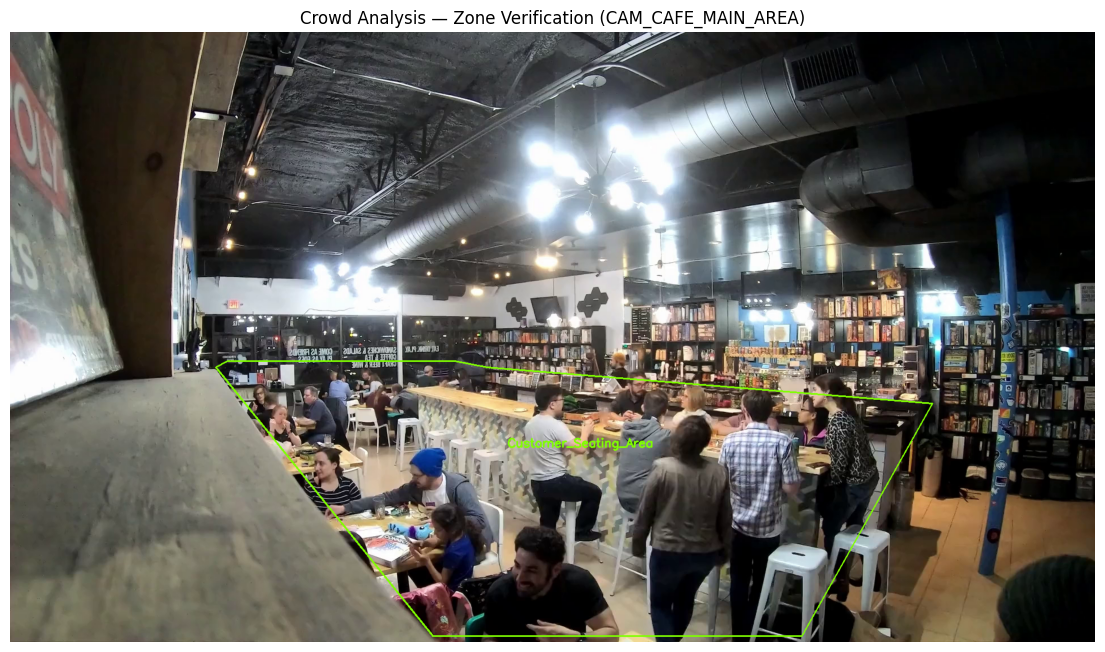

In [34]:
# Verify
verify_zone_overlays(ca_first_frame, ca_polygon_zones, f"Crowd Analysis — Zone Verification ({CA_CAMERA_ID})")

In [ ]:
# Run inference
run_inference(
    video_path           = CA_VIDEO_PATH,
    camera_id            = CA_CAMERA_ID,
    polygon_zones        = ca_polygon_zones,
    output_path          = CA_OUTPUT_PATH,
    confidence_threshold = CA_CONFIDENCE_THRESHOLD,
    save_output          = CA_SAVE_OUTPUT_VIDEO,
    db_write             = CA_DB_WRITE_ENABLED,
    overlay_color        = (0, 255, 128),
    show_count           = True,
    show_intrusion       = False
)

## Intrusion Detection

In [19]:
# Extract frame
ID_VIDEO_PATH = "Input_Videos/Intrusion_Detection/Intruder_Detection.mp4"
ID_SAVE_DIR = "zone_setup_frames/intrusion_detection"
ID_CAMERA_ID = "CAM_CLOSED_CORRIDOR"
ID_OUTPUT_PATH = "Output_Videos/Intrusion_Detection/ID_Intruder_Detection_output.avi"

#PeopleNet Confidence
ID_CONFIDENCE_THRESHOLD = 0.5
ID_SAVE_OUTPUT_VIDEO = True
ID_DB_WRITE_ENABLED = True

id_first_frame = extract_first_frame(ID_VIDEO_PATH, ID_SAVE_DIR, ID_CAMERA_ID)

Frame saved: zone_setup_frames/intrusion_detection\CAM_CLOSED_CORRIDOR.jpg
Upload to https://polygonzone.roboflow.com/ to draw zones.


In [20]:

# Paste Roboflow PolygonZone coordinates here after drawing zones
ID_ZONES = [
    {
        "zone_name"           : "Renovation_Area_Restricted",
        "camera_id"           : ID_CAMERA_ID,
        "zone_type"           : "Corridor",
        "floor"               : "Ground Floor",
        "reid_enabled"        : False,
        "track_point"         : "bottom",
        "trigger_line"        : {"points": None, "in_direction": None},
        "reid_task_map"       : {},
        "polygon_coordinates" : [
    np.array([[0.47, 0.71], [0.58, 0.71], [0.6, 0.92], [0.32, 0.89]])
],   # paste Roboflow coordinates here
    },
]

# Insert zones
id_polygon_zones = []
insert_zones(ID_ZONES, id_polygon_zones)


Zone inserted: 'Renovation_Area_Restricted' — zone_id: 98

Zones loaded: ['Renovation_Area_Restricted']


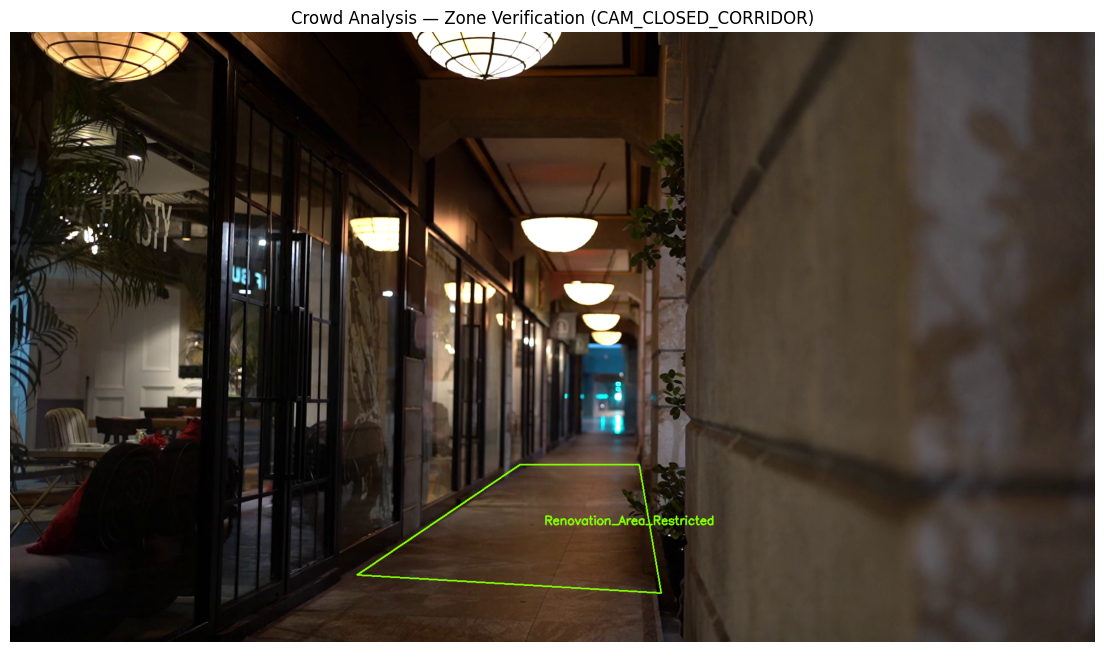

In [21]:
# Verify
verify_zone_overlays(id_first_frame, id_polygon_zones, f"Crowd Analysis — Zone Verification ({ID_CAMERA_ID})")

In [31]:
# Run inference
run_inference(
    video_path           = ID_VIDEO_PATH,
    camera_id            = ID_CAMERA_ID,
    polygon_zones        = id_polygon_zones,
    output_path          = ID_OUTPUT_PATH,
    confidence_threshold = ID_CONFIDENCE_THRESHOLD,
    save_output          = ID_SAVE_OUTPUT_VIDEO,
    db_write             = ID_DB_WRITE_ENABLED,
    overlay_color        = (0, 255, 128),
    show_count           = False,
    show_intrusion       = True
)

Inference complete — 504 frames, 219 rows written.
Intrusion detected in 219 frames.
Output saved: Output_Videos/Intrusion_Detection/ID_Intruder_Detection_output.avi


# BI Integration

<b>Make sure to pip install streamlit, plotly, and sqlalchemy.  </b> Then, type in your command line: streamlit run dashboard_app.py

# Notifications

## Setup & Define Rules

In [ ]:
rules_definitions = [
     {
        "rule_name": "High Crowd Density - Cafe Seating",
        "zone_name": "Customer_Seating_Area",
        "trigger_condition": "object_count_in_zone > threshold_max",
        "threshold_min": None,
        "threshold_max": 8,  
        "severity": "WARNING",
        "rule_type": "crowd_analysis",
        "active": True,
    },
       { "rule_name": "Intrusion - Restricted Renovation Area",
        "zone_name": "Renovation_Area_Restricted",   
        "trigger_condition": "object_class = person AND zone_type = Corridor",
        "threshold_min": None,
        "threshold_max": None,
        "severity": "CRITICAL",
        "rule_type": "intrusion_detection",
        "active": True,
    },
]

In [13]:
for rule in rules_definitions:
    cursor.execute("""
        INSERT INTO rules (rule_name, zone_id, trigger_condition, threshold_min, threshold_max, severity, rule_type, active)
        VALUES (
            %(rule_name)s,
            (SELECT zone_id FROM zones WHERE zone_name = %(zone_name)s),
            %(trigger_condition)s,
            %(threshold_min)s,
            %(threshold_max)s,
            %(severity)s,
            %(rule_type)s,
            %(active)s
        )
    """, rule)

conn.commit()
print(f"Inserted {len(rules_definitions)} rules.")

Inserted 2 rules.


In [29]:
cursor.execute("""
CREATE OR REPLACE FUNCTION evaluate_detection_rules() RETURNS TRIGGER AS $$
DECLARE
    r RECORD;
    alert_msg VARCHAR(255);
    trigger_payload JSONB;
    new_notification_id INT;
    v_zone_name VARCHAR(100);
BEGIN
    -- Look up the zone name once, since detection_events only stores zone_id
    SELECT zone_name INTO v_zone_name FROM zones WHERE zone_id = NEW.zone_id;

    -- SECURITY: intrusion
    FOR r IN SELECT rule_id, severity, zone_id FROM rules WHERE rule_type = 'intrusion_detection' AND active = TRUE LOOP
        IF NEW.zone_id = r.zone_id AND NEW.object_class = 'person' THEN
            alert_msg := format('Intrusion detected: person in %s via %s', v_zone_name, NEW.camera_id);
            trigger_payload := jsonb_build_object(
                'notification_type', 'SECURITY',
                'zone_name', v_zone_name,
                'movement_type', NEW.movement_type,
                'timestamp', NEW.timestamp,
                'image_path', NEW.image_path
            );
            INSERT INTO notifications (timestamp, rule_id, unique_detection_id, zone_id, camera_id, trigger_value, message, image_path)
            VALUES (NEW.timestamp, r.rule_id, NEW.unique_detection_id, NEW.zone_id, NEW.camera_id, trigger_payload, alert_msg, NEW.image_path)
            RETURNING notification_id INTO new_notification_id;

            PERFORM pg_notify('cv_alerts', json_build_object(
                'notification_id', new_notification_id,
                'notification_type', 'SECURITY',
                'severity', r.severity,
                'rule_type', 'intrusion_detection',
                'zone_name', v_zone_name,
                'movement_type', NEW.movement_type,
                'timestamp', NEW.timestamp,
                'image_path', NEW.image_path
            )::text);
        END IF;
    END LOOP;

    -- OPERATIONS: crowd density
    FOR r IN SELECT rule_id, severity, threshold_max, zone_id FROM rules WHERE rule_type = 'crowd_analysis' AND active = TRUE LOOP
        IF NEW.zone_id = r.zone_id AND NEW.object_count_in_zone > r.threshold_max THEN
            alert_msg := format('Crowd density alert: %s people in %s', NEW.object_count_in_zone, v_zone_name);
            trigger_payload := jsonb_build_object(
                'notification_type', 'OPERATIONS',
                'zone_name', v_zone_name,
                'object_count_in_zone', NEW.object_count_in_zone,
                'timestamp', NEW.timestamp
            );
            INSERT INTO notifications (timestamp, rule_id, unique_detection_id, zone_id, camera_id, trigger_value, message)
            VALUES (NEW.timestamp, r.rule_id, NEW.unique_detection_id, NEW.zone_id, NEW.camera_id, trigger_payload, alert_msg)
            RETURNING notification_id INTO new_notification_id;

            PERFORM pg_notify('cv_alerts', json_build_object(
                'notification_id', new_notification_id,
                'notification_type', 'OPERATIONS',
                'severity', r.severity,
                'rule_type', 'crowd_analysis',
                'zone_name', v_zone_name,
                'object_count_in_zone', NEW.object_count_in_zone,
                'timestamp', NEW.timestamp
            )::text);
        END IF;
    END LOOP;

    RETURN NEW;
END;
$$ LANGUAGE plpgsql;
""")

cursor.execute("DROP TRIGGER IF EXISTS trg_evaluate_detection_rules ON detection_events;")
cursor.execute("""
    CREATE TRIGGER trg_evaluate_detection_rules
        AFTER INSERT ON detection_events
        FOR EACH ROW
        EXECUTE FUNCTION evaluate_detection_rules();
""")
conn.commit()
print("Trigger function created and attached.")

Trigger function created and attached.


## Test

In [17]:
cursor.execute("""
    SELECT pg_notify('cv_alerts', %s)
""", (json.dumps({
    "notification_id": 0,
    "notification_type": "SECURITY",
    "severity": "CRITICAL",
    "rule_type": "intrusion_detection",
    "zone_name": "Renovation_Area_Restricted",
    "movement_type": "in",
    "timestamp": datetime.now().isoformat(),
    "image_path": "alert_crops/2026-06-20/Renovation_Area_Restricted/test.jpg"
}),))
conn.commit()
print("SECURITY test sent.")

SECURITY test sent.


In [18]:
cursor.execute("""
    SELECT pg_notify('cv_alerts', %s)
""", (json.dumps({
    "notification_id": 0,
    "notification_type": "OPERATIONS",
    "severity": "WARNING",
    "rule_type": "crowd_analysis",
    "zone_name": "Customer_Seating_Area",
    "object_count_in_zone": 11,
    "timestamp": datetime.now().isoformat()
}),))
conn.commit()
print("OPERATIONS test sent (should include staffing line, count > 8).")

OPERATIONS test sent (should include staffing line, count > 8).


In [ ]:
# ── DEFINE ZONES ───────────────────────────────────────────────────────────
# Polygon coordinates will be filled in Cell 7 after drawing
# Add or edit zones here before running the inference loop

zones = [
    {
        "zone_name"           : "Entrance A",
        "camera_id"           : "CAM_01",
        "polygon_coordinates" : None,   # filled after Cell 7
        "floor"               : "L1",
        "zone_type"           : "entrance"
    },
    {
        "zone_name"           : "Restricted Corridor",
        "camera_id"           : "CAM_01",
        "polygon_coordinates" : None,   # filled after Cell 7
        "floor"               : "L1",
        "zone_type"           : "restricted"
    }
]

for zone in zones:
    cursor.execute("""
        INSERT INTO zones (zone_name, camera_id, polygon_coordinates, floor, zone_type)
        VALUES (%s, %s, %s, %s, %s)
        ON CONFLICT DO NOTHING
    """, (
        zone["zone_name"],
        zone["camera_id"],
        json.dumps(zone["polygon_coordinates"]),
        zone["floor"],
        zone["zone_type"]
    ))

conn.commit()
print("Zones inserted.")

# ── DEFINE RULES ───────────────────────────────────────────────────────────
rules = [
    {
        "rule_name"         : "intrusion_after_hours",
        "zone_name"         : "Restricted Corridor",
        "trigger_condition" : "person_detected = TRUE AND time BETWEEN '22:00' AND '06:00'",
        "threshold_min"     : None,
        "threshold_max"     : None,
        "severity"          : "critical",
        "rule_type"         : "security",
        "active"            : True
    },
    {
        "rule_name"         : "understaffed",
        "zone_name"         : "Entrance A",
        "trigger_condition" : "staff_count < threshold_min AND customer_count > threshold_max",
        "threshold_min"     : 3.0,
        "threshold_max"     : 10.0,
        "severity"          : "warning",
        "rule_type"         : "operations",
        "active"            : True
    }
]

for rule in rules:
    # Get zone_id from zone_name
    cursor.execute("SELECT zone_id FROM zones WHERE zone_name = %s", (rule["zone_name"],))
    zone_row = cursor.fetchone()
    if zone_row:
        cursor.execute("""
            INSERT INTO rules 
            (rule_name, zone_id, trigger_condition, threshold_min, threshold_max, severity, rule_type, active)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
            ON CONFLICT DO NOTHING
        """, (
            rule["rule_name"],
            zone_row[0],
            rule["trigger_condition"],
            rule["threshold_min"],
            rule["threshold_max"],
            rule["severity"],
            rule["rule_type"],
            rule["active"]
        ))

conn.commit()
print("Rules inserted.")